# fun_RR

把 `RR.ipynb` 的回归流程封装成函数，方便在不同 `start_date` / `end_date` 时间窗口上自动化分期回测。

In [1]:
from pathlib import Path
from dataclasses import dataclass
from functools import lru_cache
import gc
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import cvxpy as cp
import time

DEFAULT_FOLD = Path(r"D:\BaiduNetdiskDownload\正则化基金数据\正则化基金数据")

STYLE_FACTORS = [
    'Beta', 'BooktoPrice', 'EarningYield', 'Growth', 'Leverage',
    'Liquidity', 'Momentum', 'NonlinearSize', 'ResidualVolatility', 'Size'
]

INDUSTRY_FACTORS = [
    '交通运输', '传媒', '公用事业', '农林牧渔',
    '化工', '医药生物', '商贸零售', '国防军工',
    '家用电器', '建筑材料', '建筑装饰', '房地产',
    '有色金属', '机械设备', '汽车', '煤炭',
    '环保', '电力设备', '电子', '石油石化',
    '社会服务', '纺织服饰', '综合', '美容护理',
    '计算机', '轻工制造', '通信', '采掘',
    '钢铁', '银行', '非银金融', '食品饮料'
]

STYLE_FACTOR_FILES = {
    'Beta': 'Beta正交后.txt',
    'BooktoPrice': 'BooktoPrice正交后.txt',
    'EarningYield': 'EarningYield正交后.txt',
    'Growth': 'Growth正交后.txt',
    'Leverage': 'Leverage正交后.txt',
    'Liquidity': 'Liquidity正交后.txt',
    'Momentum': 'Momentum正交后.txt',
    'NonlinearSize': 'NonlinearSize正交后.txt',
    'ResidualVolatility': 'ResidualVolatility正交后.txt',
    'Size': 'Size正交后.txt',
}

HOLDING_FACTOR_COVERAGE_THRESHOLD = 0.85

@dataclass
class RRRawData:
    nav: pd.DataFrame
    SH: pd.DataFrame
    fm: pd.DataFrame
    fi: pd.DataFrame
    fs: pd.DataFrame
    nav_rr: pd.DataFrame = None
    factor_data: pd.DataFrame = None


In [2]:
def _parse_date_col(df, col):
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        return df
    out = df.copy()
    out[col] = pd.to_datetime(out[col].astype(str), errors='coerce')
    return out

def prepare_rr_base_data(raw_data, verbose=True):
    """一次性准备窗口构建所需的精简 NAV 和完整因子日表。"""
    start_time = time.perf_counter()
    nav_cols = ['F_INFO_WINDCODE', 'PRICE_DATE', 'F_NAV_ADJUSTED', 'return', '1M']
    missing_nav_cols = [col for col in nav_cols if col not in raw_data.nav.columns]
    if missing_nav_cols:
        raise KeyError(f'raw_data.nav 缺少构建 rr_data 所需列: {missing_nav_cols}')

    raw_data.nav_rr = (
        raw_data.nav.loc[:, nav_cols]
        .dropna(subset=['F_INFO_WINDCODE', 'PRICE_DATE'])
        .sort_values('PRICE_DATE')
        .set_index('PRICE_DATE', drop=False)
    )
    fm_daily = (
        raw_data.fm.rename(columns={'日期': 'PRICE_DATE'})
        .sort_values('PRICE_DATE')
        .drop_duplicates('PRICE_DATE', keep='last')
    )
    fi_daily = (
        raw_data.fi.rename(columns={'TRADE_DT': 'PRICE_DATE'})
        .sort_values('PRICE_DATE')
        .drop_duplicates('PRICE_DATE', keep='last')
    )
    fs_daily = (
        raw_data.fs.rename(columns={'time': 'PRICE_DATE'})
        .sort_values('PRICE_DATE')
        .drop_duplicates('PRICE_DATE', keep='last')
    )
    raw_data.factor_data = (
        fm_daily.merge(fi_daily, on='PRICE_DATE', how='left', validate='one_to_one')
        .merge(fs_daily, on='PRICE_DATE', how='left', validate='one_to_one')
        .sort_values('PRICE_DATE')
        .set_index('PRICE_DATE', drop=False)
    )
    if verbose:
        print(f'[timing] prepare_rr_base_data: {time.perf_counter() - start_time:.2f}s')
    return raw_data

def load_rr_data(fold=DEFAULT_FOLD, verbose=True):
    """读取并预处理 RR 流程需要的原始数据。建议批量回测时只读取一次。"""
    start_time = time.perf_counter()
    fold = Path(fold)
    raw_data = RRRawData(
        nav=pd.read_feather(fold / '基金数据' / '交易日偏股型基金.feather'),
        SH=pd.read_feather(fold / '基金数据' / 'CHINAMUTUALFUNDSTOCKPORTFOLIO.feather'),
        fm=pd.read_csv(fold / '宽基指数日行情' / '宽基指数收益率.csv'),
        fi=pd.read_feather(fold / '申万一级行业' / '申万一级行业_with_dailyreturn.feather'),
        fs=pd.read_feather(fold / 'Barra_CNE5' / 'Barra风格因子收益率.feather'),
    )
    fund_type_col = 'F_INFO_TYPE'
    open_fund_type = '契约型开放式'
    if fund_type_col not in raw_data.nav.columns:
        raise KeyError(f'raw_data.nav 缺少基金开放/封闭类型列: {fund_type_col}')
    nav_rows_before = len(raw_data.nav)
    funds_before = raw_data.nav['F_INFO_WINDCODE'].nunique()
    raw_data.nav = raw_data.nav.loc[
        raw_data.nav[fund_type_col].eq(open_fund_type)
    ].copy()
    if verbose:
        print(
            f'open-end fund filter: removed '
            f'{nav_rows_before - len(raw_data.nav):,} rows and '
            f'{funds_before - raw_data.nav["F_INFO_WINDCODE"].nunique():,} funds'
        )
    raw_data.nav = _parse_date_col(raw_data.nav, 'PRICE_DATE')
    raw_data.SH = _parse_date_col(_parse_date_col(raw_data.SH, 'F_PRT_ENDDATE'), 'available_date')
    raw_data.fm = _parse_date_col(raw_data.fm, '日期')
    raw_data.fi = _parse_date_col(raw_data.fi, 'TRADE_DT')
    raw_data.fs = _parse_date_col(raw_data.fs, 'time')
    raw_data = prepare_rr_base_data(raw_data, verbose=verbose)
    if verbose:
        print(f'[timing] load_rr_data: {time.perf_counter() - start_time:.2f}s')
    return raw_data

def build_rr_data(raw_data, start_date, end_date, min_fund_days=120, max_fill_ratio=0.05, verbose=True):
    """使用一次性预处理的基础表构建单个窗口 rr_data。"""
    start_time = time.perf_counter()
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    if start_date > end_date:
        raise ValueError('start_date 不能晚于 end_date。')
    if getattr(raw_data, 'nav_rr', None) is None or getattr(raw_data, 'factor_data', None) is None:
        prepare_rr_base_data(raw_data, verbose=verbose)

    try:
        nav = raw_data.nav_rr.loc[start_date:end_date].copy()
        factor_data = raw_data.factor_data.loc[start_date:end_date].copy()
    except KeyError:
        nav = raw_data.nav_rr.loc[
            raw_data.nav_rr['PRICE_DATE'].between(start_date, end_date)
        ].copy()
        factor_data = raw_data.factor_data.loc[
            raw_data.factor_data['PRICE_DATE'].between(start_date, end_date)
        ].copy()
    nav = nav.reset_index(drop=True)
    factor_data = factor_data.reset_index(drop=True)
    trading_days = pd.Index(
        factor_data['PRICE_DATE'].dropna().drop_duplicates().sort_values(),
        name='PRICE_DATE'
    )

    fund_stats = (
        nav.groupby('F_INFO_WINDCODE', observed=True)
        .agg(
            fund_days=('PRICE_DATE', 'nunique'),
            has_1m=('1M', 'any')
        )
    )
    codes = fund_stats.index[
        fund_stats['fund_days'].ge(min_fund_days)
        & fund_stats['has_1m'].fillna(False)
    ]
    nav_for_merge = (
        nav.loc[
            nav['F_INFO_WINDCODE'].isin(codes),
            ['PRICE_DATE', 'F_INFO_WINDCODE', 'F_NAV_ADJUSTED', 'return']
        ]
        .sort_values(['F_INFO_WINDCODE', 'PRICE_DATE'])
        .drop_duplicates(['F_INFO_WINDCODE', 'PRICE_DATE'], keep='last')
    )

    if nav_for_merge.empty or trading_days.empty:
        rr_data = pd.DataFrame()
        fund_fill_stats = pd.DataFrame()
        funds_to_remove = pd.Index([])
    else:
        fund_bounds = (
            nav_for_merge.groupby('F_INFO_WINDCODE', observed=True)['PRICE_DATE']
            .agg(fund_start='min', fund_end='max')
            .reset_index()
        )
        full_index = pd.MultiIndex.from_product(
            [codes, trading_days],
            names=['F_INFO_WINDCODE', 'PRICE_DATE']
        )
        nav_aligned = full_index.to_frame(index=False).merge(
            fund_bounds,
            on='F_INFO_WINDCODE',
            how='inner',
            validate='many_to_one'
        )
        nav_aligned = nav_aligned.loc[
            nav_aligned['PRICE_DATE'].between(
                nav_aligned['fund_start'],
                nav_aligned['fund_end']
            )
        ].drop(columns=['fund_start', 'fund_end'])
        nav_aligned = nav_aligned.merge(
            nav_for_merge,
            on=['F_INFO_WINDCODE', 'PRICE_DATE'],
            how='left',
            validate='one_to_one',
            indicator=True
        )
        nav_aligned['IS_ORIGINAL_FUND_DATE'] = nav_aligned['_merge'].eq('both')
        nav_aligned['IS_FILLED_FROM_PREV_DAY'] = ~nav_aligned['IS_ORIGINAL_FUND_DATE']
        nav_aligned = nav_aligned.drop(columns='_merge').sort_values(
            ['F_INFO_WINDCODE', 'PRICE_DATE']
        )
        grouped = nav_aligned.groupby('F_INFO_WINDCODE', observed=True, sort=False)
        return_ffill = grouped['return'].ffill()
        return_bfill = grouped['return'].bfill()
        return_fill = (return_ffill + return_bfill) / 2.0
        nav_aligned['return'] = (
            nav_aligned['return'].fillna(return_fill)
            .groupby(nav_aligned['F_INFO_WINDCODE'], observed=True)
            .ffill()
            .groupby(nav_aligned['F_INFO_WINDCODE'], observed=True)
            .bfill()
        )
        nav_aligned['F_NAV_ADJUSTED'] = grouped['F_NAV_ADJUSTED'].ffill()

        rr_data = nav_aligned.merge(
            factor_data,
            on='PRICE_DATE',
            how='left',
            validate='many_to_one'
        )
        fund_fill_stats = (
            rr_data.groupby('F_INFO_WINDCODE', observed=True)
            .agg(
                total_days=('PRICE_DATE', 'size'),
                filled_days=('IS_FILLED_FROM_PREV_DAY', 'sum'),
                fill_ratio=('IS_FILLED_FROM_PREV_DAY', 'mean')
            )
            .sort_values('fill_ratio', ascending=False)
        )
        funds_to_remove = fund_fill_stats.index[
            fund_fill_stats['fill_ratio'].gt(max_fill_ratio)
        ]
        if len(funds_to_remove):
            rr_data = rr_data.loc[
                ~rr_data['F_INFO_WINDCODE'].isin(funds_to_remove)
            ].copy()

    summary = {
        'start_date': start_date,
        'end_date': end_date,
        'eligible_funds_before_fill_filter': len(codes),
        'removed_funds_by_fill_ratio': len(funds_to_remove),
        'rr_funds': rr_data['F_INFO_WINDCODE'].nunique() if not rr_data.empty else 0,
    }
    if verbose:
        print(summary)
        print(f'[timing] build_rr_data: {time.perf_counter() - start_time:.2f}s')
    return rr_data, fund_fill_stats, summary


In [3]:
def run_regularized_regression(
    rr_data,
    style_factors=STYLE_FACTORS,
    industry_factors=INDUSTRY_FACTORS,
    lambda_style=6e-5,
    solver=cp.OSQP,
    n_jobs=14,
    verbose=True
):
    """按基金并行执行带约束的正则化回归。"""
    start_time = time.perf_counter()

    if rr_data.empty:
        raise ValueError('rr_data 为空，无法回归。')

    fund_col = 'F_INFO_WINDCODE'
    return_col = 'return'
    market_col = '沪深300dailyreturn'

    style_factors = list(style_factors)
    requested_industry_factors = list(industry_factors)

    required_cols = (
        [fund_col, return_col, market_col]
        + style_factors
        + requested_industry_factors
    )

    missing_cols = [
        col for col in required_cols
        if col not in rr_data.columns
    ]
    if missing_cols:
        raise KeyError(
            f'rr_data 缺少回归所需列: {missing_cols}'
        )

    # 只复制回归真正需要的列，避免传递多余数据。
    regression_data = rr_data.loc[:, required_cols].copy()

    # return和市场收益缺失的行不会参与回归，提前一次性剔除。
    regression_data = regression_data.dropna(
        subset=[fund_col, return_col, market_col]
    )

    # 行业因子按当前回归窗口动态筛选。窗口内完全没有有效观测的断档因子
    # 不进入优化变量和行业暴露合计约束；后续能力计算会将其暴露补为 0。
    industry_numeric = regression_data.loc[:, requested_industry_factors].apply(
        pd.to_numeric,
        errors='coerce'
    )
    industry_factors = [
        factor for factor in requested_industry_factors
        if industry_numeric[factor].notna().any()
    ]
    dropped_industry_factors = [
        factor for factor in requested_industry_factors
        if factor not in industry_factors
    ]
    if not industry_factors:
        raise ValueError('当前回归窗口没有任何可用行业因子。')

    regression_data = regression_data.drop(
        columns=dropped_industry_factors
    )

    # 有效因子的局部缺失值统一填 0，避免每只基金重复处理。
    factor_cols = style_factors + industry_factors
    regression_data.loc[:, factor_cols] = (
        regression_data.loc[:, factor_cols]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0.0)
    )

    regression_data[return_col] = pd.to_numeric(
        regression_data[return_col],
        errors='coerce'
    )
    regression_data[market_col] = pd.to_numeric(
        regression_data[market_col],
        errors='coerce'
    )

    regression_data = regression_data.dropna(
        subset=[return_col, market_col]
    )

    # rr_data在这里仅扫描一次。
    fund_groups = [
        (fund, fund_data)
        for fund, fund_data in regression_data.groupby(
            fund_col,
            sort=False,
            observed=True
        )
        if len(fund_data) >= 60
    ]

    if verbose:
        if dropped_industry_factors:
            print(
                'dropped industry factors with no valid observations: '
                f'{dropped_industry_factors}'
            )
        print(
            f'regression input: '
            f'{len(regression_data):,} rows, '
            f'{len(fund_groups):,} funds'
        )

    def solve_one_fund(fund, fund_data):
        y = fund_data[return_col].to_numpy(
            dtype=np.float64,
            copy=False
        )
        market_return = fund_data[market_col].to_numpy(
            dtype=np.float64,
            copy=False
        )
        industry_matrix = fund_data[industry_factors].to_numpy(
            dtype=np.float64,
            copy=False
        )
        industry_excess_matrix = industry_matrix - market_return[:, None]
        style_matrix = fund_data[style_factors].to_numpy(
            dtype=np.float64,
            copy=False
        )

        beta_fund = cp.Variable()
        beta_industry = cp.Variable(len(industry_factors))
        beta_style = cp.Variable(len(style_factors))
        alpha = cp.Variable()

        prediction = (
            beta_fund * market_return
            + industry_excess_matrix @ beta_industry
            + style_matrix @ beta_style
            + alpha
        )

        objective = cp.Minimize(
            cp.sum_squares(y - prediction)
            + lambda_style * cp.sum_squares(beta_style)
        )

        constraints = [
            beta_fund >= 0,
            beta_fund <= 1,
            beta_industry >= 0,
            beta_industry <= 1,
            cp.sum(beta_industry) == beta_fund
        ]

        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(
                solver=solver,
                eps_abs=1e-8,
                eps_rel=1e-8,
                max_iter=100000,
                polish=True,
                verbose=False
            )
        except Exception:
            return None

        if problem.status not in (
            cp.OPTIMAL,
            cp.OPTIMAL_INACCURATE
        ):
            return None

        if (
            beta_fund.value is None
            or beta_industry.value is None
            or beta_style.value is None
            or alpha.value is None
        ):
            return None

        return {
            'F_INFO_WINDCODE': fund,
            'stock_exposure': float(beta_fund.value),
            'alpha': float(alpha.value),
            'industry_exposure': dict(zip(
                industry_factors,
                np.asarray(beta_industry.value).copy()
            )),
            'style_exposure': dict(zip(
                style_factors,
                np.asarray(beta_style.value).copy()
            ))
        }

    # threading共享内存，不需要向多个Windows子进程复制rr_data。
    results = Parallel(
        n_jobs=n_jobs,
        backend='loky',
        batch_size=16,
        pre_dispatch=32
    )(
        delayed(solve_one_fund)(fund, fund_data)
        for fund, fund_data in fund_groups
    )

    results = [
        result for result in results
        if result is not None
    ]
    results_df = pd.DataFrame(results)

    if verbose:
        elapsed = time.perf_counter() - start_time
        print(f'regression funds: {len(results_df):,}')
        print(f'[timing] run_regularized_regression: {elapsed:.2f}s')

    return results_df

In [4]:
@lru_cache(maxsize=None)
def _read_barra_factor(path):
    factor = pd.read_feather(path)
    factor['time'] = pd.to_datetime(factor['time'])
    return factor

def compute_holding_style_exposure(
    raw_data,
    rr_data,
    end_date,
    fold=DEFAULT_FOLD,
    style_factor_files=STYLE_FACTOR_FILES,
    verbose=True,
    coverage_threshold=HOLDING_FACTOR_COVERAGE_THRESHOLD
):
    """用 end_date 前最新可用持仓，计算基金持仓的 Barra 正交后风格暴露。"""
    start_time = time.perf_counter()
    if not 0 <= coverage_threshold <= 1:
        raise ValueError('coverage_threshold 必须在 0 到 1 之间。')

    fold = Path(fold)
    SH = raw_data.SH
    snapshot_date = pd.to_datetime(end_date)

    rr_fund_col = 'F_INFO_WINDCODE'
    sh_fund_col = 'S_INFO_WINDCODE'
    report_col = 'F_PRT_ENDDATE'
    available_col = 'available_date'
    stock_col = 'S_INFO_STOCKWINDCODE'
    weight_col = 'F_PRT_STKVALUETONAV'

    required_cols = [
        sh_fund_col,
        report_col,
        available_col,
        stock_col,
        weight_col
    ]
    missing_cols = [
        col for col in required_cols
        if col not in SH.columns
    ]
    if missing_cols:
        raise KeyError(f'SH 缺少必要列: {missing_cols}')

    if rr_fund_col not in rr_data.columns:
        raise KeyError(f'rr_data 缺少基金代码列 {rr_fund_col}')

    target_funds = pd.Index(
        rr_data[rr_fund_col].dropna().unique()
    )
    if len(target_funds) == 0:
        raise ValueError(
            f'rr_data 当前行数为 {len(rr_data)}，'
            f'但 {rr_fund_col} 没有可用基金代码。'
        )

    holding_all = SH.loc[:, required_cols].copy()
    holding_all[report_col] = pd.to_datetime(
        holding_all[report_col],
        errors='coerce'
    )
    holding_all[available_col] = pd.to_datetime(
        holding_all[available_col],
        errors='coerce'
    )
    holding_all[weight_col] = pd.to_numeric(
        holding_all[weight_col],
        errors='coerce'
    )

    semi_annual_or_annual = (
        (
            (holding_all[report_col].dt.month == 6)
            & (holding_all[report_col].dt.day == 30)
        )
        | (
            (holding_all[report_col].dt.month == 12)
            & (holding_all[report_col].dt.day == 31)
        )
    )

    holding_available_all = holding_all.loc[
        semi_annual_or_annual
        & holding_all[available_col].notna()
        & (holding_all[available_col] <= snapshot_date)
        & holding_all[report_col].notna()
    ].copy()

    if holding_available_all.empty:
        raise ValueError(
            f'end_date={snapshot_date.date()} '
            '前没有可用的半年/全年持仓。'
        )

    latest_holding = (
        holding_available_all[[report_col, available_col]]
        .drop_duplicates()
        .sort_values([available_col, report_col])
        .iloc[-1]
    )
    latest_report_date = latest_holding[report_col]
    latest_available_date = latest_holding[available_col]

    holding_snapshot_all = holding_available_all.loc[
        (holding_available_all[report_col] == latest_report_date)
        & (
            holding_available_all[available_col]
            == latest_available_date
        )
        & holding_available_all[stock_col].notna()
        & holding_available_all[weight_col].gt(0)
    ].copy()

    holding_snapshot = holding_snapshot_all.loc[
        holding_snapshot_all[sh_fund_col].isin(target_funds)
    ].copy()

    if holding_snapshot.empty:
        sh_sample = (
            holding_snapshot_all[sh_fund_col]
            .dropna()
            .astype(str)
            .head(5)
            .tolist()
        )
        rr_sample = (
            pd.Series(target_funds)
            .dropna()
            .astype(str)
            .head(5)
            .tolist()
        )
        raise ValueError(
            f'最新可用持仓期 {latest_report_date.date()} / '
            f'{latest_available_date.date()} 存在，'
            '但与 rr_data 基金没有匹配。'
            f'SH基金样例={sh_sample}，'
            f'rr_data基金样例={rr_sample}。'
        )

    holding_snapshot['holding_weight'] = (
        holding_snapshot[weight_col] / 100.0
    )

    holding_snapshot = (
        holding_snapshot
        .groupby(
            [sh_fund_col, stock_col],
            as_index=False
        )['holding_weight']
        .sum()
    )

    holding_stock_weight_sum = (
        holding_snapshot
        .groupby(sh_fund_col, as_index=False)['holding_weight']
        .sum()
        .rename(columns={
            'holding_weight': 'holding_stock_weight_sum'
        })
    )

    beta_all = _read_barra_factor(
        str(
            fold
            / 'Barra_CNE5'
            / style_factor_files['Beta']
        )
    )
    barra_dates = beta_all.loc[
        beta_all['time'] <= snapshot_date,
        'time'
    ].dropna()

    if barra_dates.empty:
        raise ValueError(
            f'end_date={snapshot_date.date()} '
            '前没有可用的 Barra 暴露日期。'
        )

    barra_exposure_date = barra_dates.max()

    needed_stocks = pd.Index(
        holding_snapshot[stock_col].dropna().unique()
    )

    style_exposure = pd.DataFrame({
        sh_fund_col: sorted(
            holding_snapshot[sh_fund_col]
            .dropna()
            .unique()
        )
    })

    def compute_one_barra_factor(factor_name, file_name):
        factor_wide = _read_barra_factor(
            str(fold / 'Barra_CNE5' / file_name)
        )

        available_stocks = needed_stocks.intersection(
            factor_wide.columns
        )

        factor_row = factor_wide.loc[
            factor_wide['time'] == barra_exposure_date,
            available_stocks
        ]

        if factor_row.empty:
            raise ValueError(
                f'{file_name} 找不到 Barra 日期 '
                f'{barra_exposure_date.date()}。'
            )

        factor_long = (
            factor_row.iloc[0]
            .rename(factor_name)
            .rename_axis(stock_col)
            .reset_index()
        )

        factor_long[factor_name] = pd.to_numeric(
            factor_long[factor_name],
            errors='coerce'
        )
        # 每个因子独立匹配。不能要求股票同时具备全部 Barra 因子，
        # 也不能把该因子缺失的股票暴露当成 0。
        factor_long = factor_long.dropna(subset=[factor_name])

        weighted = holding_snapshot.merge(
            factor_long,
            on=stock_col,
            how='inner'
        )

        weighted['_weighted_factor_exposure'] = (
            weighted['holding_weight']
            * weighted[factor_name]
        )

        factor_stats = (
            weighted
            .groupby(sh_fund_col, as_index=False)
            .agg(
                weighted_exposure_sum=(
                    '_weighted_factor_exposure',
                    'sum'
                ),
                matched_factor_weight=(
                    'holding_weight',
                    'sum'
                )
            )
        )

        factor_stats = factor_stats.merge(
            holding_stock_weight_sum,
            on=sh_fund_col,
            how='right',
            validate='one_to_one'
        )
        coverage_col = f'{factor_name}_coverage'
        matched_weight_col = f'{factor_name}_matched_weight_sum'
        factor_stats[coverage_col] = (
            factor_stats['matched_factor_weight']
            / factor_stats['holding_stock_weight_sum']
        )
        factor_stats[coverage_col] = factor_stats[coverage_col].clip(
            lower=0.0,
            upper=1.0
        )
        factor_stats[factor_name] = (
            factor_stats['weighted_exposure_sum']
            / factor_stats['matched_factor_weight']
        )
        factor_stats.loc[
            factor_stats[coverage_col].lt(
                coverage_threshold
            ),
            factor_name
        ] = np.nan
        factor_stats = factor_stats.rename(columns={
            'matched_factor_weight': matched_weight_col
        })

        return (
            factor_name,
            factor_stats[[
                sh_fund_col,
                factor_name,
                coverage_col,
                matched_weight_col
            ]]
        )

    factor_results = Parallel(
        n_jobs=8,
        backend='threading',
        batch_size=1
    )(
        delayed(compute_one_barra_factor)(
            factor_name,
            file_name
        )
        for factor_name, file_name
        in style_factor_files.items()
    )

    matched_stock_weight_sum = None

    for factor_name, factor_result in factor_results:
        style_exposure = style_exposure.merge(
            factor_result,
            on=sh_fund_col,
            how='left'
        )

        if matched_stock_weight_sum is None:
            matched_stock_weight_sum = factor_result[[
                sh_fund_col,
                f'{factor_name}_matched_weight_sum'
            ]].rename(columns={
                f'{factor_name}_matched_weight_sum':
                    'matched_stock_weight_sum'
            })

        if verbose:
            print(f'{factor_name} done')

    holding_style_exposure = (
        style_exposure
        .rename(columns={
            sh_fund_col: rr_fund_col
        })
        .merge(
            holding_stock_weight_sum.rename(
                columns={
                    sh_fund_col: rr_fund_col
                }
            ),
            on=rr_fund_col,
            how='left'
        )
        .merge(
            matched_stock_weight_sum.rename(
                columns={
                    sh_fund_col: rr_fund_col
                }
            ),
            on=rr_fund_col,
            how='left'
        )
        .assign(
            PRICE_DATE=snapshot_date,
            holding_report_date=latest_report_date,
            holding_available_date=latest_available_date,
            barra_exposure_date=barra_exposure_date
        )
    )

    holding_style_exposure = (
        holding_style_exposure[
            [
                rr_fund_col,
                'PRICE_DATE',
                'holding_report_date',
                'holding_available_date',
                'barra_exposure_date',
                'holding_stock_weight_sum',
                'matched_stock_weight_sum'
            ]
            + list(style_factor_files.keys())
            + [
                f'{factor_name}_coverage'
                for factor_name in style_factor_files
            ]
            + [
                f'{factor_name}_matched_weight_sum'
                for factor_name in style_factor_files
            ]
        ]
        .sort_values(rr_fund_col)
        .reset_index(drop=True)
    )

    coverage_cols = [
        f'{factor_name}_coverage'
        for factor_name in style_factor_files
    ]
    coverage_mean_by_factor = (
        holding_style_exposure[coverage_cols]
        .mean()
        .to_dict()
    )

    summary = {
        'snapshot_date': snapshot_date,
        'latest_holding_report_date':
            latest_report_date,
        'latest_holding_available_date':
            latest_available_date,
        'barra_exposure_date':
            barra_exposure_date,
        'coverage_threshold': coverage_threshold,
        'coverage_mean': holding_style_exposure[coverage_cols].stack().mean(),
        'coverage_mean_by_factor': coverage_mean_by_factor
    }

    if verbose:
        print(summary)
        print(f'[timing] compute_holding_style_exposure: {time.perf_counter() - start_time:.2f}s')

    return holding_style_exposure, summary

In [5]:
def compute_stock_selection_ability(rr_data, results_df, holding_style_exposure, style_factors=STYLE_FACTORS, industry_factors=INDUSTRY_FACTORS, verbose=True):
    """混合回归风格暴露与持仓风格暴露，计算选股能力。"""
    start_time = time.perf_counter()
    if results_df.empty:
        raise ValueError('results_df 为空，请先成功运行回归暴露。')
    if holding_style_exposure.empty:
        raise ValueError('holding_style_exposure 为空，请先成功运行持仓 Barra 暴露。')

    fund_col = 'F_INFO_WINDCODE'
    market_col = '沪深300dailyreturn'
    return_col = 'return'

    required_rr_cols = [fund_col, 'PRICE_DATE', return_col, market_col] + list(style_factors) + list(industry_factors)
    missing_rr_cols = [col for col in required_rr_cols if col not in rr_data.columns]
    if missing_rr_cols:
        raise KeyError(f'rr_data 缺少计算模型收益所需列: {missing_rr_cols}')
    missing_result_cols = [col for col in [fund_col, 'stock_exposure', 'style_exposure', 'industry_exposure'] if col not in results_df.columns]
    if missing_result_cols:
        raise KeyError(f'results_df 缺少必要列: {missing_result_cols}')
    missing_holding_cols = [col for col in [fund_col] + list(style_factors) if col not in holding_style_exposure.columns]
    if missing_holding_cols:
        raise KeyError(f'holding_style_exposure 缺少必要列: {missing_holding_cols}')

    reg_style_exposure = pd.json_normalize(results_df['style_exposure']).reindex(columns=style_factors)
    reg_style_exposure.columns = [f'{col}_reg_style_exposure' for col in style_factors]
    reg_style_exposure.insert(0, fund_col, results_df[fund_col].values)
    reg_industry_exposure = pd.json_normalize(results_df['industry_exposure']).reindex(columns=industry_factors).fillna(0.0)
    reg_industry_exposure.columns = [f'{col}_industry_exposure' for col in industry_factors]
    reg_industry_exposure.insert(0, fund_col, results_df[fund_col].values)
    reg_base_exposure = results_df[[fund_col, 'stock_exposure']].copy()
    holding_coverage_cols = [
        f'{factor}_coverage'
        for factor in style_factors
        if f'{factor}_coverage' in holding_style_exposure.columns
    ]
    holding_style = holding_style_exposure[
        [fund_col] + list(style_factors) + holding_coverage_cols
    ].copy().rename(columns={
        col: f'{col}_holding_style_exposure'
        for col in style_factors
    })

    mix_style_exposure = (
        reg_base_exposure.merge(reg_style_exposure, on=fund_col, how='inner', validate='one_to_one')
        .merge(reg_industry_exposure, on=fund_col, how='inner', validate='one_to_one')
        .merge(holding_style, on=fund_col, how='inner', validate='one_to_one')
    )
    for factor in style_factors:
        reg_col = f'{factor}_reg_style_exposure'
        holding_col = f'{factor}_holding_style_exposure'
        mix_col = f'{factor}_mix_style_exposure'
        # 覆盖率不足的持仓暴露为 NaN，此时完全退回回归暴露；
        # 持仓暴露有效时，继续使用原有的 50%/50% 混合结构。
        mix_style_exposure[mix_col] = np.where(
            mix_style_exposure[holding_col].notna(),
            (
                mix_style_exposure[reg_col]
                + mix_style_exposure[holding_col]
            ) / 2.0,
            mix_style_exposure[reg_col]
        )

    model_cols = ([fund_col, 'stock_exposure'] + [f'{factor}_mix_style_exposure' for factor in style_factors] + [f'{factor}_reg_style_exposure' for factor in style_factors] + [f'{factor}_holding_style_exposure' for factor in style_factors] + holding_coverage_cols + [f'{industry}_industry_exposure' for industry in industry_factors])
    rr_data_with_mix_exposure = rr_data.merge(mix_style_exposure[model_cols], on=fund_col, how='inner', validate='many_to_one')
    if rr_data_with_mix_exposure.empty:
        raise ValueError('rr_data 与 mix_style_exposure 合并后为空，请检查基金代码交集。')
    
    market_model_return = rr_data_with_mix_exposure['stock_exposure'] * rr_data_with_mix_exposure[market_col].fillna(0.0)
    industry_model_return = np.zeros(len(rr_data_with_mix_exposure), dtype=float)
    for industry in industry_factors:
        industry_excess_return = (
            rr_data_with_mix_exposure[industry].fillna(0.0).to_numpy(dtype=float)
            - rr_data_with_mix_exposure[market_col].fillna(0.0).to_numpy(dtype=float)
        )
        industry_model_return += industry_excess_return * rr_data_with_mix_exposure[f'{industry}_industry_exposure'].fillna(0.0).to_numpy(dtype=float)
    style_model_return = np.zeros(len(rr_data_with_mix_exposure), dtype=float)
    for factor in style_factors:
        style_model_return += rr_data_with_mix_exposure[factor].fillna(0.0).to_numpy(dtype=float) * rr_data_with_mix_exposure[f'{factor}_mix_style_exposure'].fillna(0.0).to_numpy(dtype=float)
    
    rr_data_with_mix_exposure['market_model_return'] = market_model_return
    rr_data_with_mix_exposure['industry_model_return'] = industry_model_return
    rr_data_with_mix_exposure['style_model_return_mix'] = style_model_return
    rr_data_with_mix_exposure['model_return_mix'] = rr_data_with_mix_exposure['market_model_return'] + rr_data_with_mix_exposure['industry_model_return'] + rr_data_with_mix_exposure['style_model_return_mix']
    rr_data_with_mix_exposure['stock_selection_return_mix'] = rr_data_with_mix_exposure[return_col] - rr_data_with_mix_exposure['model_return_mix']

    stock_selection_ability = (
        rr_data_with_mix_exposure.groupby(fund_col, as_index=False)
        .agg(stock_selection_ability=('stock_selection_return_mix', 'mean'), obs_count=('stock_selection_return_mix', 'count'))
        .sort_values('stock_selection_ability', ascending=False)
        .reset_index(drop=True)
    )
    summary = {'regression_funds': results_df[fund_col].nunique(), 'holding_exposure_funds': holding_style_exposure[fund_col].nunique(), 'mix_exposure_funds': mix_style_exposure[fund_col].nunique(), 'final_stock_selection_ability': stock_selection_ability['stock_selection_ability'].mean()}
    if verbose:
        print(summary)
        print(f'[timing] compute_stock_selection_ability: {time.perf_counter() - start_time:.2f}s')
    return stock_selection_ability, mix_style_exposure, rr_data_with_mix_exposure, summary


In [6]:
def compute_timing_ability(
    results_df,
    raw_data,
    start_date,
    end_date,
    lambda_style=6e-5,
    previous_results_df=None,
    previous_end_date=None,
    verbose=True,
    previous_previous_results_df=None,
    previous_previous_end_date=None,
    rr_data=None,
    style_factors=STYLE_FACTORS,
    industry_factors=INDUSTRY_FACTORS,
    solver=cp.OSQP,
    n_jobs=14,
    min_obs=60
):
    """独立并行运行传统 Treynor-Mazuy 二次回归，gamma 为择时能力。"""
    start_time = time.perf_counter()
    if rr_data is None:
        rr_data, _, _ = build_rr_data(
            raw_data=raw_data,
            start_date=start_date,
            end_date=end_date,
            verbose=False
        )
    if rr_data.empty:
        raise ValueError('rr_data 为空，无法执行 TM 回归。')

    fund_col = 'F_INFO_WINDCODE'
    return_col = 'return'
    market_col = '沪深300dailyreturn'
    required_cols = [fund_col, return_col, market_col]
    missing_cols = [col for col in required_cols if col not in rr_data.columns]
    if missing_cols:
        raise KeyError(f'rr_data 缺少 TM 回归所需列: {missing_cols}')

    timing_data = rr_data.loc[:, required_cols].copy()
    timing_data = timing_data.dropna(
        subset=[fund_col, return_col, market_col]
    )
    if results_df is not None and fund_col in results_df.columns:
        timing_data = timing_data.loc[
            timing_data[fund_col].isin(results_df[fund_col].dropna().unique())
        ].copy()

    timing_data[return_col] = pd.to_numeric(
        timing_data[return_col], errors='coerce'
    )
    timing_data[market_col] = pd.to_numeric(
        timing_data[market_col], errors='coerce'
    )
    timing_data = timing_data.dropna(subset=[return_col, market_col])

    fund_groups = [
        (fund, fund_data)
        for fund, fund_data in timing_data.groupby(
            fund_col, sort=False, observed=True
        )
        if len(fund_data) >= min_obs
    ]
    if verbose:
        print(
            f'TM regression input: {len(timing_data):,} rows, '
            f'{len(fund_groups):,} funds'
        )

    def solve_one_fund(fund, fund_data):
        y = fund_data[return_col].to_numpy(dtype=np.float64, copy=False)
        market_return = fund_data[market_col].to_numpy(
            dtype=np.float64, copy=False
        )
        market_squared = np.square(market_return)
        design_matrix = np.column_stack([
            np.ones(len(fund_data), dtype=np.float64),
            market_return,
            market_squared,
        ])
        try:
            coefficients, _, rank, _ = np.linalg.lstsq(
                design_matrix,
                y,
                rcond=None
            )
        except np.linalg.LinAlgError:
            return None
        if rank < design_matrix.shape[1]:
            return None
        tm_alpha, tm_beta, gamma = coefficients
        if not np.isfinite(coefficients).all():
            return None

        fitted_return = design_matrix @ coefficients
        residual = y - fitted_return
        ss_res = float(residual @ residual)
        centered_return = y - y.mean()
        ss_total = float(centered_return @ centered_return)
        return {
            fund_col: fund,
            'tm_alpha': float(tm_alpha),
            'tm_beta': float(tm_beta),
            'gamma': float(gamma),
            'timing_ability': float(gamma),
            'tm_industry_exposure': {},
            'tm_style_exposure': {},
            'tm_r_squared': np.nan if ss_total <= 0 else 1.0 - ss_res / ss_total,
            'tm_obs_count': int(len(fund_data)),
        }

    results = Parallel(
        n_jobs=n_jobs,
        backend='loky',
        batch_size=16,
        pre_dispatch=32
    )(
        delayed(solve_one_fund)(fund, fund_data)
        for fund, fund_data in fund_groups
    )
    timing_ability = pd.DataFrame([
        result for result in results if result is not None
    ])
    if timing_ability.empty:
        raise ValueError(f'没有基金满足传统 TM 回归要求（至少 {min_obs} 个有效观测）。')
    timing_ability = timing_ability.sort_values(
        'timing_ability', ascending=False
    ).reset_index(drop=True)
    summary = {
        'timing_funds': timing_ability[fund_col].nunique(),
        'final_timing_ability': timing_ability['timing_ability'].mean(),
        'timing_mean_r_squared': timing_ability['tm_r_squared'].mean(),
        'timing_mean_obs_count': timing_ability['tm_obs_count'].mean(),
    }
    if verbose:
        print(summary)
        print(f'[timing] compute_timing_ability: {time.perf_counter() - start_time:.2f}s')
    return timing_ability, summary


In [7]:
def _parse_yyyymmdd(series):
    raw = series.astype('string').str.replace(r'\.0$', '', regex=True)
    raw = raw.mask(raw.isin(['0', 'nan', '<NA>', 'None', '']))
    return pd.to_datetime(raw, format='%Y%m%d', errors='coerce')


def add_ability_score(ability_df, ability_col, score_col='score', verbose=True):
    """按能力列的百分位排名生成 0-100 score。"""
    start_time = time.perf_counter()
    if ability_df.empty:
        raise ValueError('ability_df 为空。')
    if ability_col not in ability_df.columns:
        raise KeyError(f'ability_df 缺少能力列 {ability_col}')
    scored = ability_df.copy()
    scored[ability_col] = pd.to_numeric(scored[ability_col], errors='coerce')
    scored[score_col] = scored[ability_col].rank(pct=True, method='average') * 100.0
    scored = scored.sort_values(score_col, ascending=False).reset_index(drop=True)
    if verbose:
        print(f'[timing] add_ability_score({ability_col}): {time.perf_counter() - start_time:.2f}s')
    return scored


def compute_comprehensive_ability(stock_selection_ability, timing_ability, verbose=True):
    """合并选股 score 和择时 score，计算等权综合 score。"""
    start_time = time.perf_counter()
    fund_col = 'F_INFO_WINDCODE'
    required_stock_cols = [fund_col, 'stock_selection_ability', 'score']
    required_timing_cols = [fund_col, 'timing_ability', 'score']
    missing_stock_cols = [col for col in required_stock_cols if col not in stock_selection_ability.columns]
    if missing_stock_cols:
        raise KeyError(f'stock_selection_ability 缺少综合排名所需列: {missing_stock_cols}')
    missing_timing_cols = [col for col in required_timing_cols if col not in timing_ability.columns]
    if missing_timing_cols:
        raise KeyError(f'timing_ability 缺少综合排名所需列: {missing_timing_cols}')

    comprehensive_ability = (
        stock_selection_ability[required_stock_cols]
        .rename(columns={'score': 'stock_selection_score'})
        .merge(
            timing_ability[required_timing_cols].rename(columns={'score': 'timing_score'}),
            on=fund_col,
            how='inner',
            validate='one_to_one'
        )
    )
    if comprehensive_ability.empty:
        raise ValueError('选股能力和择时能力没有基金交集，无法计算综合排名。')
    comprehensive_ability['score'] = (comprehensive_ability['stock_selection_score'] + comprehensive_ability['timing_score']) / 2.0
    comprehensive_ability = comprehensive_ability.sort_values('score', ascending=False).reset_index(drop=True)
    comprehensive_ability['comprehensive_rank'] = np.arange(1, len(comprehensive_ability) + 1)
    if verbose:
        print(f'[timing] compute_comprehensive_ability: {time.perf_counter() - start_time:.2f}s')
    return comprehensive_ability


def load_manager_data(fold=DEFAULT_FOLD, verbose=True):
    """基金经理数据只读取和预处理一次。"""
    start_time = time.perf_counter()
    manager_path = Path(fold) / '基金数据' / 'CHINAMUTUALFUNDMANAGER_202605221351(1).csv'
    required_cols = [
        'F_INFO_WINDCODE', 'F_INFO_FUNDMANAGER', 'F_INFO_FUNDMANAGER_ID',
        'F_INFO_MANAGER_STARTDATE', 'F_INFO_MANAGER_LEAVEDATE'
    ]
    manager = pd.read_csv(manager_path, usecols=required_cols)
    manager['F_INFO_MANAGER_STARTDATE'] = _parse_yyyymmdd(manager['F_INFO_MANAGER_STARTDATE'])
    manager['F_INFO_MANAGER_LEAVEDATE'] = _parse_yyyymmdd(manager['F_INFO_MANAGER_LEAVEDATE'])
    manager['F_INFO_FUNDMANAGER_ID'] = manager['F_INFO_FUNDMANAGER_ID'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(5)
    manager['F_INFO_FUNDMANAGER'] = manager['F_INFO_FUNDMANAGER'].astype('string')
    if verbose:
        print(f'[timing] load_manager_data: {time.perf_counter() - start_time:.2f}s')
    return manager


def build_fund_selection_snapshot(manager_data, raw_data, end_date, target_funds, verbose=True):
    """为一个窗口生成可供多种能力排名复用的经理和基金公司快照。"""
    start_time = time.perf_counter()
    fund_col = 'F_INFO_WINDCODE'
    name_col = 'F_INFO_FUNDMANAGER'
    id_col = 'F_INFO_FUNDMANAGER_ID'
    start_col = 'F_INFO_MANAGER_STARTDATE'
    leave_col = 'F_INFO_MANAGER_LEAVEDATE'
    company_col = 'fund_com'
    price_col = 'PRICE_DATE'
    snapshot_date = pd.to_datetime(end_date)
    target_funds = pd.Index(target_funds).dropna().unique()
    if len(target_funds) == 0:
        raise ValueError('target_funds 为空。')

    required_manager_cols = [fund_col, name_col, id_col, start_col, leave_col]
    missing_manager_cols = [col for col in required_manager_cols if col not in manager_data.columns]
    if missing_manager_cols:
        raise KeyError(f'manager_data 缺少必要列: {missing_manager_cols}')
    required_nav_cols = [fund_col, price_col, company_col]
    missing_nav_cols = [col for col in required_nav_cols if col not in raw_data.nav.columns]
    if missing_nav_cols:
        raise KeyError(f'raw_data.nav 缺少必要列: {missing_nav_cols}')

    manager = manager_data.loc[manager_data[fund_col].isin(target_funds), required_manager_cols]
    active_manager = manager.loc[
        manager[start_col].notna()
        & manager[start_col].le(snapshot_date)
        & (manager[leave_col].isna() | manager[leave_col].ge(snapshot_date))
    ].copy()
    active_manager['manager_source'] = 'active_on_end_date'
    funds_with_active = pd.Index(active_manager[fund_col].dropna().unique())
    fallback_manager = manager.loc[
        ~manager[fund_col].isin(funds_with_active)
        & manager[start_col].notna()
        & manager[start_col].le(snapshot_date)
    ].copy()
    if not fallback_manager.empty:
        fallback_manager = (
            fallback_manager.sort_values([fund_col, start_col, leave_col], ascending=[True, False, False])
            .drop_duplicates(fund_col, keep='first')
        )
        fallback_manager['manager_source'] = 'latest_before_end_date'

    manager_effective = pd.concat([active_manager, fallback_manager], ignore_index=True)
    manager_info = (
        manager_effective.dropna(subset=[fund_col, id_col])
        .groupby(fund_col, as_index=False)
        .agg(
            manager_ids=(id_col, lambda x: tuple(sorted(set(x.dropna().astype(str))))),
            manager_names=(name_col, lambda x: '、'.join(sorted(set(x.dropna().astype(str))))),
            manager_source=('manager_source', lambda x: 'active_on_end_date' if (x == 'active_on_end_date').any() else 'latest_before_end_date')
        )
    )
    # pandas 新版本可能把 agg 返回的 tuple 转成 ndarray，统一还原为 tuple。
    manager_info['manager_ids'] = manager_info['manager_ids'].map(
        lambda value: tuple(value) if isinstance(value, (list, tuple, np.ndarray, pd.Series)) else tuple()
    )

    nav_company = raw_data.nav.loc[
        raw_data.nav[fund_col].isin(target_funds),
        [fund_col, price_col, company_col]
    ].copy()
    if not pd.api.types.is_datetime64_any_dtype(nav_company[price_col]):
        nav_company[price_col] = pd.to_datetime(nav_company[price_col].astype(str), errors='coerce')
    nav_company[company_col] = nav_company[company_col].astype('string')
    company_info = (
        nav_company.loc[nav_company[price_col].notna() & nav_company[price_col].le(snapshot_date)]
        .sort_values([fund_col, price_col])
        .drop_duplicates(fund_col, keep='last')
        [[fund_col, company_col]]
    )
    selection_snapshot = (
        pd.DataFrame({fund_col: target_funds})
        .merge(manager_info, on=fund_col, how='left', validate='one_to_one')
        .merge(company_info, on=fund_col, how='left', validate='one_to_one')
    )
    if verbose:
        print(f'[timing] build_fund_selection_snapshot: {time.perf_counter() - start_time:.2f}s')
    return selection_snapshot


def select_top15_unique_manager(ability_df, end_date, fold=DEFAULT_FOLD, raw_data=None, ability_col='stock_selection_ability', top_n=15, max_funds_per_company=2, verbose=True, selection_snapshot=None, manager_data=None):
    """按能力排序并执行经理去重和基金公司数量限制。"""
    start_time = time.perf_counter()
    if ability_df.empty:
        raise ValueError('ability_df 为空。')
    fund_col = 'F_INFO_WINDCODE'
    company_col = 'fund_com'
    snapshot_date = pd.to_datetime(end_date)
    if fund_col not in ability_df.columns:
        raise KeyError(f'ability_df 缺少基金代码列 {fund_col}')
    if ability_col not in ability_df.columns:
        raise KeyError(f'ability_df 缺少能力列 {ability_col}')
    if selection_snapshot is None:
        if raw_data is None:
            raw_data = load_rr_data(fold)
        if manager_data is None:
            manager_data = load_manager_data(fold)
        selection_snapshot = build_fund_selection_snapshot(
            manager_data=manager_data,
            raw_data=raw_data,
            end_date=end_date,
            target_funds=ability_df[fund_col].dropna().unique(),
            verbose=verbose
        )

    required_snapshot_cols = [fund_col, 'manager_ids', 'manager_names', 'manager_source', company_col]
    missing_snapshot_cols = [col for col in required_snapshot_cols if col not in selection_snapshot.columns]
    if missing_snapshot_cols:
        raise KeyError(f'selection_snapshot 缺少必要列: {missing_snapshot_cols}')
    ranked = (
        ability_df.sort_values(ability_col, ascending=False).reset_index(drop=True)
        .merge(selection_snapshot[required_snapshot_cols], on=fund_col, how='left', validate='one_to_one')
    )
    ranked['original_rank'] = np.arange(1, len(ranked) + 1)

    selected_rows = []
    removed_rows = []
    used_manager_ids = set()
    company_counts = {}
    for _, row in ranked.iterrows():
        manager_ids = row.get('manager_ids')
        if isinstance(manager_ids, (list, tuple, np.ndarray, pd.Series)):
            manager_ids = tuple(str(manager_id) for manager_id in manager_ids if pd.notna(manager_id))
        else:
            manager_ids = tuple()
        if len(manager_ids) == 0:
            removed = row.copy()
            removed['remove_reason'] = 'missing_manager'
            removed_rows.append(removed)
            continue
        repeated = sorted(set(manager_ids).intersection(used_manager_ids))
        if repeated:
            removed = row.copy()
            removed['remove_reason'] = 'duplicate_manager'
            removed['duplicate_manager_ids'] = '|'.join(repeated)
            removed_rows.append(removed)
            continue
        company = row.get(company_col)
        if pd.isna(company) or str(company).strip() == '':
            removed = row.copy()
            removed['remove_reason'] = 'missing_company'
            removed_rows.append(removed)
            continue
        company = str(company)
        if company_counts.get(company, 0) >= max_funds_per_company:
            removed = row.copy()
            removed['remove_reason'] = 'duplicate_company_limit'
            removed['duplicate_company'] = company
            removed_rows.append(removed)
            continue
        selected_rows.append(row)
        used_manager_ids.update(manager_ids)
        company_counts[company] = company_counts.get(company, 0) + 1
        if len(selected_rows) >= top_n:
            break

    top_unique_manager = pd.DataFrame(selected_rows).reset_index(drop=True)
    removed_by_manager_rule = pd.DataFrame(removed_rows).reset_index(drop=True)
    if top_unique_manager.empty:
        reason_counts = (
            removed_by_manager_rule['remove_reason'].value_counts().to_dict()
            if 'remove_reason' in removed_by_manager_rule.columns
            else {}
        )
        raise ValueError(
            '基金经理去重后没有选出基金。'
            f'候选基金数={len(ranked)}，排除原因={reason_counts}'
        )
    top_unique_manager['selected_rank'] = np.arange(1, len(top_unique_manager) + 1)
    summary = {
        'snapshot_date': snapshot_date,
        'selected_funds': len(top_unique_manager),
        'unique_manager_ids': len(used_manager_ids),
        'unique_companies': len(company_counts),
        'max_company_count': max(company_counts.values()) if company_counts else 0,
        'removed_before_filling_top_n': len(removed_by_manager_rule)
    }
    if verbose:
        print(summary)
        print(f'[timing] select_top15_unique_manager({ability_col}): {time.perf_counter() - start_time:.2f}s')
    return top_unique_manager, removed_by_manager_rule, summary


In [8]:
def run_rr_window(start_date, end_date, fold=DEFAULT_FOLD, raw_data=None, manager_data=None, lambda_style=6e-5, keep_intermediate=True, verbose=True, previous_results_df=None, previous_end_date=None, previous_previous_results_df=None, previous_previous_end_date=None):
    """完整运行一个 RR 时间窗口，默认返回所有主要中间结果和最终结果。"""
    window_start_time = time.perf_counter()
    if raw_data is None:
        raw_data = load_rr_data(fold, verbose=verbose)
    if manager_data is None:
        manager_data = load_manager_data(fold, verbose=verbose)

    rr_data, fund_fill_stats, rr_summary = build_rr_data(raw_data=raw_data, start_date=start_date, end_date=end_date, verbose=verbose)
    results_df = run_regularized_regression(rr_data=rr_data, lambda_style=lambda_style, verbose=verbose)
    timing_ability, timing_summary = compute_timing_ability(results_df=results_df, raw_data=raw_data, start_date=start_date, end_date=end_date, lambda_style=lambda_style, previous_results_df=previous_results_df, previous_end_date=previous_end_date, verbose=verbose, previous_previous_results_df=previous_previous_results_df, previous_previous_end_date=previous_previous_end_date, rr_data=rr_data)
    holding_style_exposure, holding_summary = compute_holding_style_exposure(raw_data=raw_data, rr_data=rr_data, end_date=end_date, fold=fold, verbose=verbose)
    stock_selection_ability, mix_style_exposure, rr_data_with_mix_exposure, ability_summary = compute_stock_selection_ability(rr_data=rr_data, results_df=results_df, holding_style_exposure=holding_style_exposure, verbose=verbose)
    stock_selection_ability = add_ability_score(stock_selection_ability, ability_col='stock_selection_ability', verbose=verbose)
    timing_ability = add_ability_score(timing_ability, ability_col='timing_ability', verbose=verbose)
    comprehensive_ability = compute_comprehensive_ability(stock_selection_ability=stock_selection_ability, timing_ability=timing_ability, verbose=verbose)
    all_target_funds = pd.unique(pd.concat([
        stock_selection_ability['F_INFO_WINDCODE'],
        timing_ability['F_INFO_WINDCODE'],
        comprehensive_ability['F_INFO_WINDCODE']
    ], ignore_index=True))
    selection_snapshot = build_fund_selection_snapshot(manager_data=manager_data, raw_data=raw_data, end_date=end_date, target_funds=all_target_funds, verbose=verbose)
    top15_unique_manager, removed_by_manager_rule, manager_summary = select_top15_unique_manager(ability_df=stock_selection_ability, end_date=end_date, selection_snapshot=selection_snapshot, ability_col='score', top_n=15, max_funds_per_company=2, verbose=verbose)
    top15_timing_unique_manager, removed_timing_by_manager_rule, timing_selection_summary = select_top15_unique_manager(ability_df=timing_ability, end_date=end_date, selection_snapshot=selection_snapshot, ability_col='score', top_n=15, max_funds_per_company=2, verbose=verbose)
    top15_comprehensive_unique_manager, removed_comprehensive_by_manager_rule, comprehensive_selection_summary = select_top15_unique_manager(ability_df=comprehensive_ability, end_date=end_date, selection_snapshot=selection_snapshot, ability_col='score', top_n=15, max_funds_per_company=2, verbose=verbose)

    summary = {
        **rr_summary,
        **{f'holding_{k}': v for k, v in holding_summary.items()},
        **ability_summary,
        **timing_summary,
        **{f'manager_{k}': v for k, v in manager_summary.items()},
        **{f'timing_selection_{k}': v for k, v in timing_selection_summary.items()},
        **{f'comprehensive_selection_{k}': v for k, v in comprehensive_selection_summary.items()},
    }
    end_date = pd.to_datetime(end_date)

    fm = raw_data.fm.copy()
    fm['日期'] = pd.to_datetime(fm['日期'].astype(str), errors='coerce')
    trading_days = pd.Index(
        fm['日期'].dropna().drop_duplicates().sort_values()
    )

    # end_date 可能是季度末前最近交易日，先还原到所在自然季度末，再取下一个自然季度末。
    current_quarter_end = end_date + pd.offsets.QuarterEnd(0)
    next_quarter_end = current_quarter_end + pd.offsets.QuarterEnd(1)

    # 找 next_quarter_end 当天或之前最近一个交易日，但必须晚于 end_date。
    candidate_days = trading_days[
        (trading_days > end_date)
        & (trading_days <= next_quarter_end)
    ]

    if candidate_days.empty:
        raise ValueError(f'{end_date.date()} 后到 {next_quarter_end.date()} 之间没有可用交易日。')

    sell_date = candidate_days[-1]
    summary['sell_date'] = sell_date

    def actual_return(buy_date, sell_date, target_funds):
        function_start_time = time.perf_counter()
        buy_date = pd.to_datetime(buy_date)
        sell_date = pd.to_datetime(sell_date)
        target_funds = pd.Index(target_funds).dropna().unique()

        nav_source = raw_data.nav
        valid_mask = (
            nav_source['F_INFO_WINDCODE'].isin(target_funds)
            & nav_source['PRICE_DATE'].notna()
            & nav_source['F_NAV_ADJUSTED'].notna()
            & nav_source['PRICE_DATE'].le(sell_date)
        )
        nav_for_return = nav_source.loc[
            valid_mask,
            ['F_INFO_WINDCODE', 'PRICE_DATE', 'F_NAV_ADJUSTED']
        ].sort_values(['F_INFO_WINDCODE', 'PRICE_DATE'])

        buy_nav = (
            nav_for_return.loc[nav_for_return['PRICE_DATE'] <= buy_date]
            .drop_duplicates('F_INFO_WINDCODE', keep='last')
            [['F_INFO_WINDCODE', 'PRICE_DATE', 'F_NAV_ADJUSTED']]
            .rename(columns={'PRICE_DATE': 'buy_nav_date', 'F_NAV_ADJUSTED': 'buy_nav'})
        )
        sell_nav = (
            nav_for_return.drop_duplicates('F_INFO_WINDCODE', keep='last')
            [['F_INFO_WINDCODE', 'PRICE_DATE', 'F_NAV_ADJUSTED']]
            .rename(columns={'PRICE_DATE': 'sell_nav_date', 'F_NAV_ADJUSTED': 'sell_nav'})
        )

        fund_return_base = pd.DataFrame({'F_INFO_WINDCODE': target_funds}).merge(
            buy_nav,
            on='F_INFO_WINDCODE',
            how='left'
        ).merge(
            sell_nav,
            on='F_INFO_WINDCODE',
            how='left'
        )
        fund_return_base['actual_return'] = (
            fund_return_base['sell_nav']
            / fund_return_base['buy_nav']
            - 1
        )

        if verbose:
            print(f'[timing] actual_return(shared): {time.perf_counter() - function_start_time:.2f}s')
        return fund_return_base

    all_backtest_funds = pd.unique(pd.concat([
        stock_selection_ability['F_INFO_WINDCODE'],
        timing_ability['F_INFO_WINDCODE'],
        comprehensive_ability['F_INFO_WINDCODE']
    ], ignore_index=True))
    fund_return_base = actual_return(
        buy_date=end_date,
        sell_date=sell_date,
        target_funds=all_backtest_funds
    )

    def backtest_ability(ability_df, top15_df, ability_col, fund_return_base):
        function_start_time = time.perf_counter()
        ability_sorted = ability_df.sort_values(ability_col, ascending=False).reset_index(drop=True)
        fund_return = ability_sorted[['F_INFO_WINDCODE']].merge(
            fund_return_base,
            on='F_INFO_WINDCODE',
            how='left',
            validate='one_to_one'
        )
        n = len(fund_return)
        fund_return['decile'] = (
            np.floor(np.arange(n) / n * 10)
            .astype(int)
            + 1
        )
        fund_return['decile'] = fund_return['decile'].clip(upper=10)
        decile_result = (
            fund_return
            .groupby('decile', as_index=False)
            .agg(
                actual_return=('actual_return', 'mean'),
                actual_return_count=('actual_return', 'count')
            )
        )
        top15_return = (
            top15_df[['F_INFO_WINDCODE']]
            .merge(
                fund_return[['F_INFO_WINDCODE', 'actual_return']],
                on='F_INFO_WINDCODE',
                how='left'
            )
            .head(15)['actual_return']
            .mean()
        )
        if verbose:
            print(f'[timing] backtest_ability({ability_col}): {time.perf_counter() - function_start_time:.2f}s')
        return fund_return, decile_result, top15_return

    # 十分组回测和 TOP15 平均收益
    fund_return, decile_result, top15_return = backtest_ability(stock_selection_ability, top15_unique_manager, ability_col='stock_selection_ability', fund_return_base=fund_return_base)
    timing_fund_return, timing_decile_result, timing_top15_return = backtest_ability(timing_ability, top15_timing_unique_manager, ability_col='timing_ability', fund_return_base=fund_return_base)
    comprehensive_fund_return, comprehensive_decile_result, comprehensive_top15_return = backtest_ability(comprehensive_ability, top15_comprehensive_unique_manager, ability_col='score', fund_return_base=fund_return_base)
    summary['top15_return'] = top15_return
    summary['timing_top15_return'] = timing_top15_return
    summary['comprehensive_top15_return'] = comprehensive_top15_return
    output = {
        'stock_selection_ability': stock_selection_ability,
        'timing_ability': timing_ability,
        'comprehensive_ability': comprehensive_ability,
        'top15_unique_manager': top15_unique_manager,
        'top15_timing_unique_manager': top15_timing_unique_manager,
        'top15_comprehensive_unique_manager': top15_comprehensive_unique_manager,
        'removed_by_manager_rule': removed_by_manager_rule,
        'removed_timing_by_manager_rule': removed_timing_by_manager_rule,
        'removed_comprehensive_by_manager_rule': removed_comprehensive_by_manager_rule,
        'fund_return': fund_return,
        'timing_fund_return': timing_fund_return,
        'comprehensive_fund_return': comprehensive_fund_return,
        'decile_result': decile_result,
        'timing_decile_result': timing_decile_result,
        'comprehensive_decile_result': comprehensive_decile_result,
        'top15_return': top15_return,
        'timing_top15_return': timing_top15_return,
        'comprehensive_top15_return': comprehensive_top15_return,
        'summary': summary,
        'results_df': results_df
    }
    if keep_intermediate:
        output.update({
            'rr_data': rr_data,
            'fund_fill_stats': fund_fill_stats,
            'holding_style_exposure': holding_style_exposure,
            'mix_style_exposure': mix_style_exposure,
            'rr_data_with_mix_exposure': rr_data_with_mix_exposure,
        })
    window_elapsed = time.perf_counter() - window_start_time
    summary['window_elapsed_seconds'] = window_elapsed
    if verbose:
        print(f'[timing] run_rr_window {pd.to_datetime(start_date).date()} ~ {pd.to_datetime(end_date).date()}: {window_elapsed:.2f}s')
    return output 


In [9]:
def make_quarterly_rolling_windows(global_start_date, global_end_date, raw_data=None, fold=DEFAULT_FOLD, lookback_trading_days=120, include_incomplete_start=False, verbose=True):
    """生成季度末滚动窗口。

    给定总开始日期和总结束日期，自动寻找区间内的 3/31、6/30、9/30、12/31
    将每个季度末修正为当日或之前最近一个交易日，再往前取 lookback_trading_days 个交易日作为窗口开始日。

    参数
    ----
    global_start_date : str or datetime-like
        总区间开始日期。季度结束日必须不早于这个日期。
    global_end_date : str or datetime-like
        总区间结束日期。季度结束日必须不晚于这个日期。
    raw_data : RRRawData, optional
        已经由 load_rr_data() 读取的数据。传入后可避免重复读取。
    fold : Path or str
        数据目录。raw_data 未传入时会用它读取交易日数据。
    lookback_trading_days : int
        每个窗口向前回看的交易日数量。默认 120。
    include_incomplete_start : bool
        如果某个季度末之前不足 lookback_trading_days 个交易日，是否仍保留并用最早可用交易日作为 start_date。
    verbose : bool
        是否打印窗口数量和首尾窗口。

    返回
    ----
    list[tuple[pd.Timestamp, pd.Timestamp]]
        可直接传给 run_rr_windows(windows, raw_data=raw_data)。
    """
    start_time = time.perf_counter()
    global_start_date = pd.to_datetime(global_start_date)
    global_end_date = pd.to_datetime(global_end_date)
    if global_start_date > global_end_date:
        raise ValueError('global_start_date 不能晚于 global_end_date。')
    if lookback_trading_days <= 0:
        raise ValueError('lookback_trading_days 必须为正整数。')

    if raw_data is None:
        raw_data = load_rr_data(fold, verbose=verbose)

    fm = raw_data.fm.copy()
    fm['日期'] = pd.to_datetime(fm['日期'].astype(str), errors='coerce')
    all_trading_days = pd.Index(fm['日期'].dropna().drop_duplicates().sort_values())
    trading_days = all_trading_days[all_trading_days <= global_end_date]
    window_end_days = all_trading_days[(all_trading_days >= global_start_date) & (all_trading_days <= global_end_date)]
    if trading_days.empty or window_end_days.empty:
        raise ValueError('给定总区间内没有可用交易日。')

    natural_quarter_ends = pd.date_range(global_start_date, global_end_date, freq='QE')
    windows = []
    used_end_dates = set()

    for natural_end in natural_quarter_ends:
        candidate_days = window_end_days[window_end_days <= natural_end]
        if len(candidate_days) == 0:
            continue

        end_date = candidate_days[-1]
        if end_date in used_end_dates:
            continue
        used_end_dates.add(end_date)

        end_pos = trading_days.get_loc(end_date)
        start_pos = end_pos - lookback_trading_days + 1
        if start_pos < 0:
            if not include_incomplete_start:
                continue
            start_pos = 0

        start_date = trading_days[start_pos]
        windows.append((pd.Timestamp(start_date), pd.Timestamp(end_date)))

    if verbose:
        print('quarterly rolling windows:', len(windows))
        if windows:
            print('first window:', windows[0][0].date(), '~', windows[0][1].date())
            print('last window:', windows[-1][0].date(), '~', windows[-1][1].date())
        print(f'[timing] make_quarterly_rolling_windows: {time.perf_counter() - start_time:.2f}s')

    return windows


In [10]:
def run_rr_windows(windows, fold=DEFAULT_FOLD, raw_data=None, manager_data=None, lambda_style=6e-5, keep_intermediate=False, verbose=True): 
    """批量运行多个窗口。默认不保留大中间表，以降低内存占用。如需中间大表可把keep_intermediate=False改为True""" 
    batch_start_time = time.perf_counter() 
    if raw_data is None: raw_data = load_rr_data(fold, verbose=verbose) 
    if manager_data is None: manager_data = load_manager_data(fold, verbose=verbose) 
    outputs = {} 
    for start_date, end_date in windows: 
        window_start_time = time.perf_counter() 
        key = (pd.to_datetime(start_date), pd.to_datetime(end_date)) 
        if verbose: print(f'\n===== RR window {key[0].date()} ~ {key[1].date()} =====') 
        outputs[key] = run_rr_window(start_date=start_date, end_date=end_date, fold=fold, raw_data=raw_data, manager_data=manager_data, lambda_style=lambda_style, keep_intermediate=keep_intermediate, verbose=verbose) 
        if verbose: print(f'[timing] completed window {key[0].date()} ~ {key[1].date()}: {time.perf_counter() - window_start_time:.2f}s') 
    if verbose: print(f'[timing] run_rr_windows total ({len(outputs)} windows): {time.perf_counter() - batch_start_time:.2f}s') 
    return outputs

## 使用示例

先 `raw_data = load_rr_data()` 读取一次，然后对多个窗口反复调用。

In [ ]:
# 多窗口示例
raw_data = load_rr_data()
manager_data = load_manager_data()
windows = make_quarterly_rolling_windows('20090630', '20250930', raw_data=raw_data)
outs = run_rr_windows(windows, raw_data=raw_data, manager_data=manager_data, keep_intermediate=False, verbose=False)
summary_df = pd.DataFrame([v['summary'] for v in outs.values()])
summary_df

open-end fund filter: removed 47,507 rows and 68 funds
[timing] prepare_rr_base_data: 1.52s
[timing] load_rr_data: 5.51s
[timing] load_manager_data: 0.19s
quarterly rolling windows: 68
first window: 2008-12-30 ~ 2009-06-30
last window: 2025-09-25 ~ 2026-03-31
[timing] make_quarterly_rolling_windows: 0.01s


,start_date,end_date,eligible_funds_before_fill_filter,removed_funds_by_fill_ratio,rr_funds,holding_snapshot_date,holding_latest_holding_report_date,holding_latest_holding_available_date,holding_barra_exposure_date,holding_coverage_threshold,...,comprehensive_selection_selected_funds,comprehensive_selection_unique_manager_ids,comprehensive_selection_unique_companies,comprehensive_selection_max_company_count,comprehensive_selection_removed_before_filling_top_n,sell_date,top15_return,timing_top15_return,comprehensive_top15_return,window_elapsed_seconds
0,2008-12-30,2009-06-30,229,0,229,2009-06-30,2008-12-31,2009-03-31,2009-06-30,0.85,...,15,18,11,2,0,2009-09-30,-0.001970,-0.008528,-0.010183,9.099560
1,2009-04-13,2009-09-30,234,0,234,2009-09-30,2009-06-30,2009-08-31,2009-09-30,0.85,...,15,18,14,2,2,2009-12-31,0.175566,0.160589,0.155012,3.503193
2,2009-07-09,2009-12-31,256,0,256,2009-12-31,2009-06-30,2009-08-31,2009-12-31,0.85,...,15,18,11,2,1,2010-03-31,-0.007379,-0.029279,-0.018747,3.372841
3,2009-09-29,2010-03-31,268,0,268,2010-03-31,2009-12-31,2010-03-31,2010-03-31,0.85,...,15,19,13,2,5,2010-06-30,-0.141375,-0.127087,-0.142063,3.306905
4,2009-12-30,2010-06-30,288,0,288,2010-06-30,2009-12-31,2010-03-31,2010-06-30,0.85,...,15,17,12,2,1,2010-09-30,0.197960,0.177714,0.185157,3.295166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,2024-09-27,2025-03-31,4140,0,4140,2025-03-31,2024-12-31,2025-03-31,2025-03-31,0.85,...,15,17,13,2,12,2025-06-30,0.106340,0.039184,0.097084,19.317461
64,2024-12-27,2025-06-30,4189,0,4189,2025-06-30,2024-12-31,2025-03-31,2025-06-30,0.85,...,15,20,14,2,7,2025-09-30,0.244697,0.366135,0.279575,19.557523
65,2025-04-10,2025-09-30,4305,0,4305,2025-09-30,2025-06-30,2025-08-31,2025-09-30,0.85,...,15,15,15,1,14,2025-12-31,0.003934,0.031364,0.041279,21.133855
66,2025-07-09,2025-12-31,4346,0,4346,2025-12-31,2025-06-30,2025-08-31,2025-11-28,0.85,...,15,15,12,2,11,2026-03-31,-0.100659,-0.042215,-0.051409,21.974035


In [ ]:
import pickle
with open('outs.pkl', 'wb') as f:
    pickle.dump(outs, f)

In [12]:
def build_decile_cum_return(outs, decile_key, verbose=True):
    '''连接每个滚动窗口的十分组收益，计算各组的累计收益曲线'''
    start_time = time.perf_counter()
    decile_returns = []

    for (start_date, end_date), out in outs.items():
        df = out[decile_key].copy()
        df['start_date'] = start_date
        df['end_date'] = end_date
        decile_returns.append(df)

    decile_returns = pd.concat(decile_returns, ignore_index=True)
    decile_returns = decile_returns.sort_values(['decile', 'end_date'])

    decile_returns['cum_return'] = (
        decile_returns
        .groupby('decile')['actual_return']
        .transform(lambda x: (1 + x.fillna(0)).cumprod())
    )

    cum_return_pivot = decile_returns.pivot(
        index='end_date',
        columns='decile',
        values='cum_return'
    )

    if verbose:
        print(f'[timing] build_decile_cum_return({decile_key}): {time.perf_counter() - start_time:.2f}s')
    return decile_returns, cum_return_pivot

In [13]:
stock_decile_cum, stock_decile_cum_pivot = build_decile_cum_return(
    outs,
    decile_key='decile_result'
)

stock_decile_cum_pivot

[timing] build_decile_cum_return(decile_result): 0.03s


decile,1,2,3,4,5,6,7,8,9,10
end_date,,,,,,,,,,
2009-06-30,0.989157,0.984435,0.987603,0.971973,0.963291,0.965843,0.977144,0.965153,0.957812,0.962047
2009-09-30,1.168528,1.148296,1.154206,1.137488,1.131456,1.126448,1.129642,1.117469,1.123190,1.112354
2009-12-31,1.161389,1.112032,1.133644,1.094013,1.093189,1.086079,1.089692,1.078347,1.089523,1.074695
2010-03-31,0.997780,0.963239,0.985803,0.932177,0.927013,0.922671,0.918560,0.909098,0.930319,0.900279
2010-06-30,1.189258,1.142906,1.158129,1.079245,1.085254,1.078872,1.080689,1.070017,1.107104,1.069642
...,...,...,...,...,...,...,...,...,...,...
2025-03-31,4.422359,3.675341,3.581954,3.250536,2.846352,2.539305,2.489184,2.256799,2.373036,1.975369
2025-06-30,5.702662,4.718630,4.553305,4.012651,3.475206,3.098523,3.096266,2.776220,2.962956,2.610617
2025-09-30,5.529612,4.613804,4.455520,3.997522,3.456071,3.089971,3.084494,2.758971,2.923889,2.556407


In [14]:
timing_decile_cum, timing_decile_cum_pivot = build_decile_cum_return(
    outs,
    decile_key='timing_decile_result'
)

timing_decile_cum_pivot

[timing] build_decile_cum_return(timing_decile_result): 0.03s


decile,1,2,3,4,5,6,7,8,9,10
end_date,,,,,,,,,,
2009-06-30,0.985368,0.972536,0.992767,0.971267,0.973836,0.974437,0.966130,0.980074,0.957961,0.947653
2009-09-30,1.149149,1.132814,1.173226,1.127823,1.134023,1.140749,1.125129,1.147600,1.111926,1.103416
2009-12-31,1.109362,1.111804,1.131323,1.089795,1.088802,1.110399,1.097569,1.104104,1.083887,1.079538
2010-03-31,0.965830,0.940395,0.951651,0.918073,0.933828,0.942775,0.939471,0.944611,0.926306,0.917643
2010-06-30,1.142536,1.117857,1.108584,1.088559,1.094367,1.102750,1.112729,1.106467,1.096706,1.086122
...,...,...,...,...,...,...,...,...,...,...
2025-03-31,3.046375,2.793622,2.695923,2.680630,3.239463,3.077649,3.085573,3.012459,2.900530,2.304702
2025-06-30,4.074078,3.594108,3.354067,3.197902,3.921293,3.822642,3.820965,3.766181,3.720262,2.901730
2025-09-30,4.125746,3.597936,3.355332,3.209336,3.914384,3.819328,3.793335,3.711760,3.562805,2.668436


In [15]:
comprehensive_decile_cum, comprehensive_decile_cum_pivot = build_decile_cum_return(
    outs,
    decile_key='comprehensive_decile_result'
)

comprehensive_decile_cum_pivot

[timing] build_decile_cum_return(comprehensive_decile_result): 0.04s


decile,1,2,3,4,5,6,7,8,9,10
end_date,,,,,,,,,,
2009-06-30,0.987001,0.986917,0.979337,0.981025,0.981548,0.978180,0.957096,0.954126,0.970563,0.948010
2009-09-30,1.150075,1.154581,1.153460,1.149048,1.147230,1.141312,1.114037,1.118075,1.128332,1.092086
2009-12-31,1.117411,1.128340,1.117618,1.123682,1.121945,1.093495,1.076855,1.083926,1.089202,1.058476
2010-03-31,0.954287,0.969033,0.965502,0.955511,0.952488,0.940020,0.914541,0.924081,0.925126,0.884051
2010-06-30,1.124353,1.155310,1.125714,1.119718,1.119998,1.112651,1.070372,1.087434,1.100407,1.041842
...,...,...,...,...,...,...,...,...,...,...
2025-03-31,3.610603,3.532860,3.286931,2.932637,3.119805,2.841153,2.547957,2.583185,2.597272,1.961359
2025-06-30,4.736273,4.503479,4.082603,3.637834,3.888998,3.561076,3.157582,3.180655,3.232682,2.510829
2025-09-30,4.800661,4.487692,4.075256,3.629535,3.840247,3.446854,3.101779,3.136438,3.163496,2.414189


<Axes: title={'center': 'Comprehensive Decile Cumulative Return'}, xlabel='end_date'>

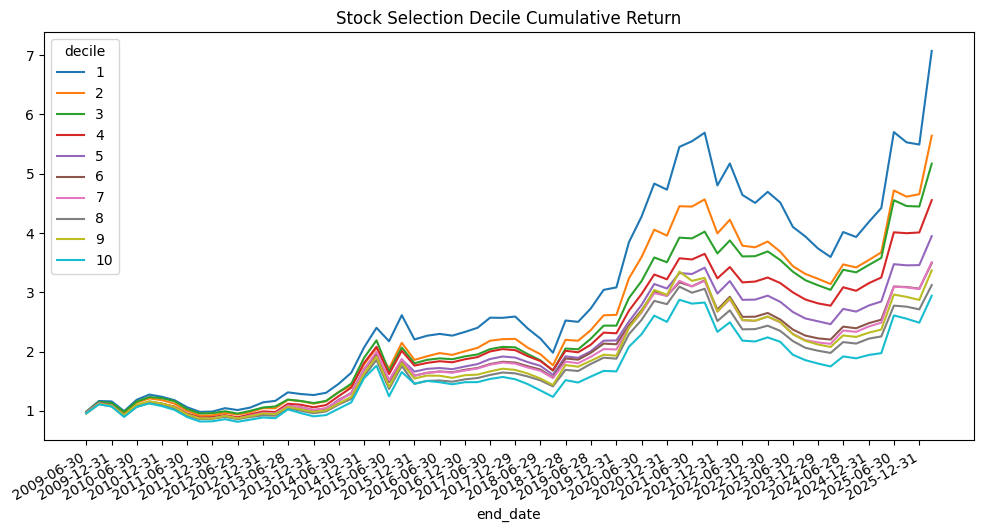

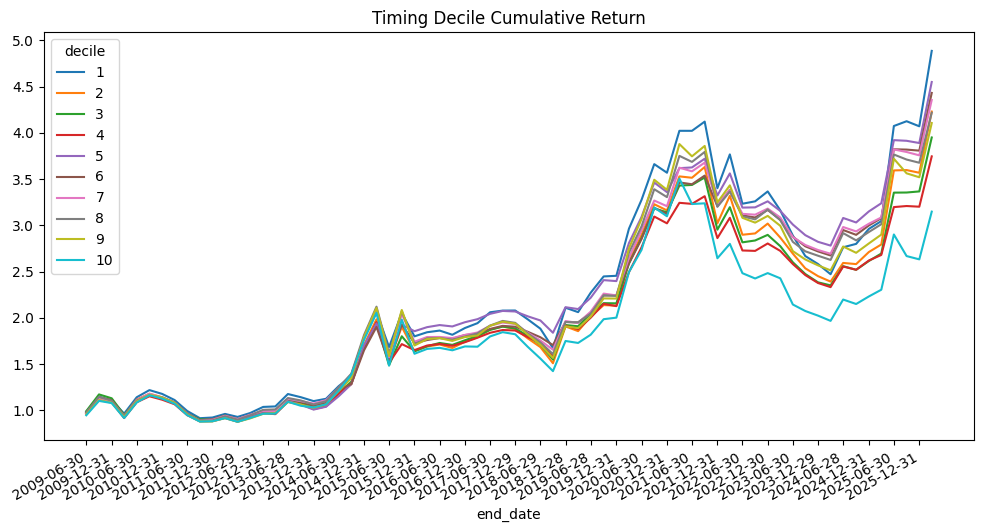

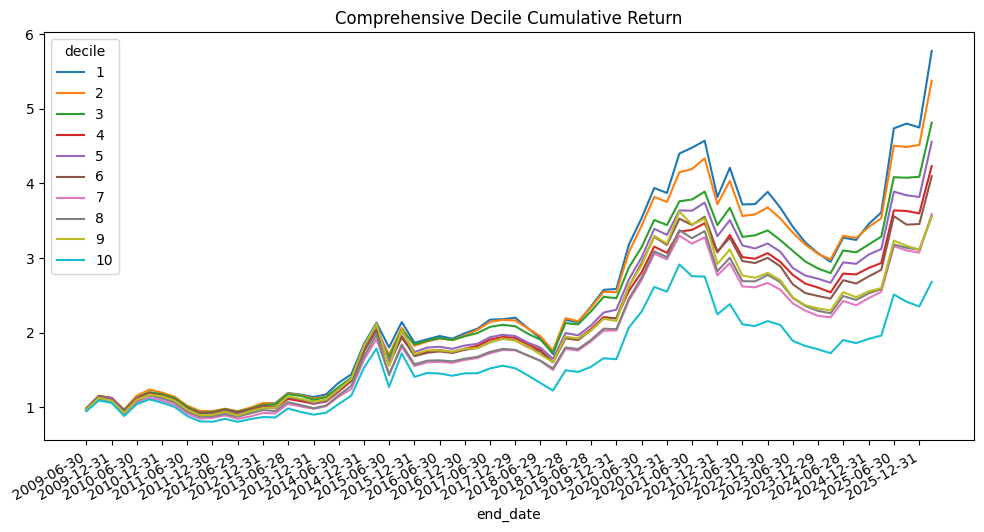

In [16]:
ax = stock_decile_cum_pivot.plot(
    figsize=(12, 6),
    title='Stock Selection Decile Cumulative Return',
    xticks=stock_decile_cum_pivot.index[::2]  # 季度数据每隔2期，即半年
)

timing_decile_cum_pivot.plot(
    figsize=(12, 6),
    title='Timing Decile Cumulative Return',
    xticks=timing_decile_cum_pivot.index[::2]
)

comprehensive_decile_cum_pivot.plot(
    figsize=(12, 6),
    title='Comprehensive Decile Cumulative Return',
    xticks=comprehensive_decile_cum_pivot.index[::2]
)

In [17]:
# 检验top15基金是否在第一分组
all(
    bool(
        set(out['comprehensive_fund_return'].query('decile == 1')['F_INFO_WINDCODE'])
        & set(out['top15_comprehensive_unique_manager']['F_INFO_WINDCODE'])
    )
    for out in outs.values()
)

True

# 综合评分十分组季度多空收益

In [18]:
def build_comprehensive_long_short_return(
    outs,
    decile_key='comprehensive_decile_result',
    long_decile=1,
    short_decile=10,
    plot=True,
    figsize=(14, 6),
    title='Comprehensive Score Quarterly Long-Short Return',
    verbose=True
):
    """计算综合评分十分组的季度多空收益、胜率和平均收益，并绘制柱状图。

    多空收益定义为高分组（默认第 1 组）平均收益减低分组（默认第 10 组）平均收益。
    统计只使用两个分组收益均有效的季度；缺少任一分组的季度保留在明细中，但不计入汇总。
    """
    import time
    import matplotlib.pyplot as plt

    start_time = time.perf_counter()
    if not isinstance(outs, dict) or len(outs) == 0:
        raise ValueError('outs 必须是非空的窗口结果字典。')
    if long_decile == short_decile:
        raise ValueError('long_decile 和 short_decile 不能相同。')

    quarterly_rows = []
    for (start_date, end_date), out in outs.items():
        if decile_key not in out:
            raise KeyError(f'窗口 {(start_date, end_date)} 缺少结果 {decile_key}')

        decile_result = out[decile_key]
        required_cols = {'decile', 'actual_return'}
        missing_cols = required_cols.difference(decile_result.columns)
        if missing_cols:
            raise KeyError(
                f'{decile_key} 缺少必要列: {sorted(missing_cols)}'
            )

        decile_return = (
            decile_result[['decile', 'actual_return']]
            .drop_duplicates('decile', keep='last')
            .set_index('decile')['actual_return']
        )
        count_by_decile = (
            decile_result
            .drop_duplicates('decile', keep='last')
            .set_index('decile')
        )
        long_return = pd.to_numeric(
            pd.Series([decile_return.get(long_decile)]),
            errors='coerce'
        ).iloc[0]
        short_return = pd.to_numeric(
            pd.Series([decile_return.get(short_decile)]),
            errors='coerce'
        ).iloc[0]
        long_count = (
            count_by_decile.at[long_decile, 'actual_return_count']
            if 'actual_return_count' in count_by_decile.columns
            and long_decile in count_by_decile.index
            else np.nan
        )
        short_count = (
            count_by_decile.at[short_decile, 'actual_return_count']
            if 'actual_return_count' in count_by_decile.columns
            and short_decile in count_by_decile.index
            else np.nan
        )
        is_valid = pd.notna(long_return) and pd.notna(short_return)
        long_short_return = (
            long_return - short_return
            if is_valid
            else np.nan
        )
        quarterly_rows.append({
            'window_start_date': pd.to_datetime(start_date),
            'window_end_date': pd.to_datetime(end_date),
            'long_decile': long_decile,
            'short_decile': short_decile,
            'long_return': long_return,
            'short_return': short_return,
            'long_short_return': long_short_return,
            'long_return_count': long_count,
            'short_return_count': short_count,
            'is_valid': is_valid,
            'is_win': (
                long_short_return > 0
                if is_valid
                else pd.NA
            )
        })

    quarterly_long_short = (
        pd.DataFrame(quarterly_rows)
        .sort_values('window_end_date')
        .reset_index(drop=True)
    )
    valid_returns = quarterly_long_short.loc[
        quarterly_long_short['is_valid'],
        'long_short_return'
    ]
    valid_quarters = int(valid_returns.size)
    winning_quarters = int(valid_returns.gt(0).sum())
    win_rate = (
        winning_quarters / valid_quarters
        if valid_quarters
        else np.nan
    )
    average_long_short_return = (
        valid_returns.mean()
        if valid_quarters
        else np.nan
    )
    summary = {
        'decile_key': decile_key,
        'long_decile': long_decile,
        'short_decile': short_decile,
        'total_quarters': len(quarterly_long_short),
        'valid_quarters': valid_quarters,
        'winning_quarters': winning_quarters,
        'win_rate': win_rate,
        'average_long_short_return': average_long_short_return
    }

    ax = None
    if plot:
        plot_data = quarterly_long_short.loc[
            quarterly_long_short['is_valid']
        ].copy()
        if plot_data.empty:
            raise ValueError('没有同时包含多头组和空头组收益的有效季度。')

        colors = np.where(
            plot_data['long_short_return'].ge(0),
            "#ff0000",
            "#379f4f"
        )
        fig, ax = plt.subplots(figsize=figsize)
        ax.bar(
            plot_data['window_end_date'],
            plot_data['long_short_return'],
            width=55,
            color=colors,
            alpha=0.85
        )
        ax.axhline(0.0, color='black', linewidth=1.0)
        ax.set_xlabel('Window End Date')
        ax.set_ylabel('Long-Short Return (Decile 1 - Decile 10)')
        ax.set_title(
            f'{title}\n'
            f'Win Rate: {win_rate:.2%} | '
            f'Average Quarterly Long-Short Return: '
            f'{average_long_short_return:.2%}'
        )
        ax.grid(axis='y', alpha=0.25)
        fig.autofmt_xdate()
        fig.tight_layout()

    if verbose:
        print(summary)
        print(
            '[timing] build_comprehensive_long_short_return: '
            f'{time.perf_counter() - start_time:.2f}s'
        )

    return quarterly_long_short, summary, ax

{'decile_key': 'comprehensive_decile_result', 'long_decile': 1, 'short_decile': 10, 'total_quarters': 68, 'valid_quarters': 68, 'winning_quarters': 47, 'win_rate': 0.6911764705882353, 'average_long_short_return': np.float64(0.01020366337292775)}
[timing] build_comprehensive_long_short_return: 0.12s


{'decile_key': 'comprehensive_decile_result',
 'long_decile': 1,
 'short_decile': 10,
 'total_quarters': 68,
 'valid_quarters': 68,
 'winning_quarters': 47,
 'win_rate': 0.6911764705882353,
 'average_long_short_return': np.float64(0.01020366337292775)}

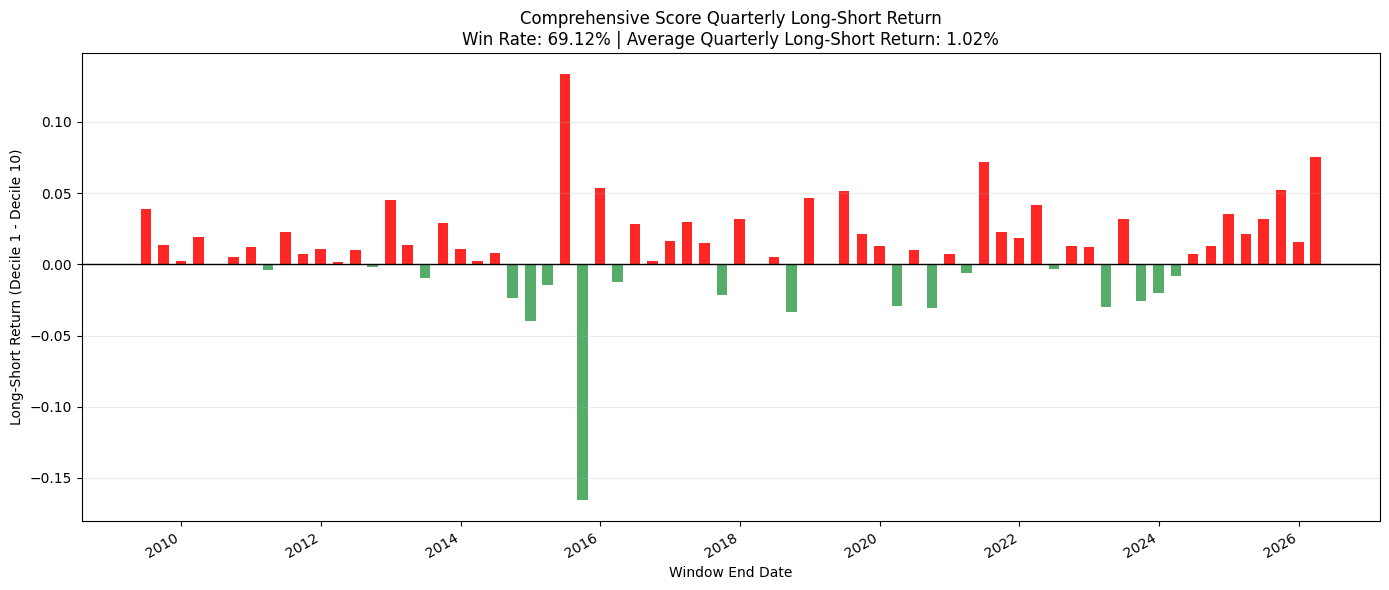

In [19]:
comprehensive_long_short, comprehensive_long_short_summary, comprehensive_long_short_ax = (
    build_comprehensive_long_short_return(outs)
)

comprehensive_long_short_summary


# 选股能力十分组季度多空收益

In [20]:
def build_stock_selection_long_short_return(
    outs,
    decile_key='decile_result',
    long_decile=1,
    short_decile=10,
    plot=True,
    figsize=(14, 6),
    title='Stock Selection Ability Quarterly Long-Short Return',
    verbose=True
):
    """计算选股能力十分组的季度多空收益、胜率和平均收益，并绘制柱状图。"""
    start_time = time.perf_counter()
    quarterly_long_short, summary, ax = build_comprehensive_long_short_return(
        outs=outs,
        decile_key=decile_key,
        long_decile=long_decile,
        short_decile=short_decile,
        plot=plot,
        figsize=figsize,
        title=title,
        verbose=False
    )
    if verbose:
        print(summary)
        print(
            '[timing] build_stock_selection_long_short_return: '
            f'{time.perf_counter() - start_time:.2f}s'
        )
    return quarterly_long_short, summary, ax

{'decile_key': 'decile_result', 'long_decile': 1, 'short_decile': 10, 'total_quarters': 68, 'valid_quarters': 68, 'winning_quarters': 49, 'win_rate': 0.7205882352941176, 'average_long_short_return': np.float64(0.011966824036160888)}
[timing] build_stock_selection_long_short_return: 0.12s


{'decile_key': 'decile_result',
 'long_decile': 1,
 'short_decile': 10,
 'total_quarters': 68,
 'valid_quarters': 68,
 'winning_quarters': 49,
 'win_rate': 0.7205882352941176,
 'average_long_short_return': np.float64(0.011966824036160888)}

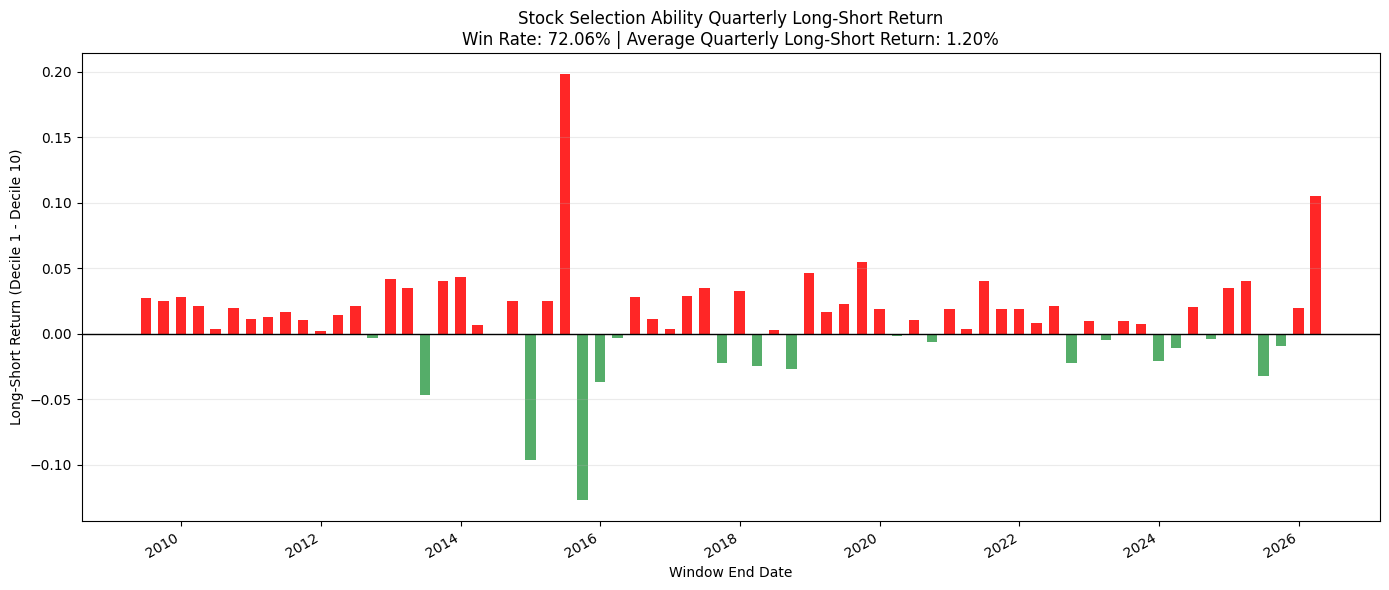

In [21]:
stock_selection_long_short, stock_selection_long_short_summary, stock_selection_long_short_ax = (
    build_stock_selection_long_short_return(outs)
)

stock_selection_long_short_summary

# 附录
### 结果调用：

In [22]:
# # 所有窗口
# list(outs.keys())[:5]

# # 第一个窗口
# window_key = next(iter(outs))

# # 该窗口包含的全部结果名称
# list(outs[window_key].keys())

In [23]:
# [
#     # 最终能力结果
#     'stock_selection_ability',
#     'timing_ability',
#     'comprehensive_ability',

#     # TOP15结果
#     'top15_unique_manager',
#     'top15_timing_unique_manager',
#     'top15_comprehensive_unique_manager',

#     # 基金经理规则剔除结果
#     'removed_by_manager_rule',
#     'removed_timing_by_manager_rule',
#     'removed_comprehensive_by_manager_rule',

#     # 下期收益及十分组回测
#     'fund_return',
#     'timing_fund_return',
#     'comprehensive_fund_return',
#     'decile_result',
#     'timing_decile_result',
#     'comprehensive_decile_result',

#     # TOP15组合收益
#     'top15_return',
#     'timing_top15_return',
#     'comprehensive_top15_return',

#     # 汇总信息
#     'summary',

#     # 中间结果
#     'rr_data',
#     'fund_fill_stats',
#     'results_df',
#     'holding_style_exposure',
#     'mix_style_exposure',
#     'rr_data_with_mix_exposure'
# ]
# # 获取某个窗口的结果
# window_key = next(iter(outs))
# window_result = outs[window_key]

# results_df = window_result['results_df']
# industry_exposure = results_df[
#     ['F_INFO_WINDCODE', 'industry_exposure']
# ]

# style_exposure = results_df[
#     ['F_INFO_WINDCODE', 'style_exposure']
# ]

# stock_ability = window_result['stock_selection_ability']
# timing_ability = window_result['timing_ability']
# comprehensive_ability = window_result['comprehensive_ability']
# # 合并所有窗口的同类结果
# def collect_window_result(outs, result_key):
#     """合并所有窗口中指定名称的 DataFrame。"""
#     frames = []

#     for (start_date, end_date), result in outs.items():
#         value = result[result_key]

#         if not isinstance(value, pd.DataFrame):
#             continue

#         df = value.copy()

#         # fund_fill_stats 的基金代码可能位于索引中
#         if df.index.name is not None:
#             df = df.reset_index()

#         df.insert(0, 'window_end_date', end_date)
#         df.insert(0, 'window_start_date', start_date)
#         frames.append(df)

#     return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
# # 使用：

# all_regression_results = collect_window_result(outs, 'results_df')
# all_stock_ability = collect_window_result(outs, 'stock_selection_ability')
# all_timing_ability = collect_window_result(outs, 'timing_ability')
# all_comprehensive_ability = collect_window_result(
#     outs, 'comprehensive_ability'
# )

# all_top15 = collect_window_result(outs, 'top15_unique_manager')
# all_fund_return = collect_window_result(outs, 'fund_return')
# all_decile_result = collect_window_result(outs, 'decile_result')
# # 展开行业和风格暴露
# # 回归行业暴露
# industry_wide = pd.concat(
#     [
#         all_regression_results[
#             ['window_start_date', 'window_end_date', 'F_INFO_WINDCODE']
#         ].reset_index(drop=True),
#         all_regression_results['industry_exposure']
#         .apply(pd.Series)
#         .reset_index(drop=True)
#     ],
#     axis=1
# )

# # 回归风格暴露
# style_wide = pd.concat(
#     [
#         all_regression_results[
#             ['window_start_date', 'window_end_date', 'F_INFO_WINDCODE']
#         ].reset_index(drop=True),
#         all_regression_results['style_exposure']
#         .apply(pd.Series)
#         .reset_index(drop=True)
#     ],
#     axis=1
# )

# industry_wide.head()

调用实例：

In [24]:
print(outs[(pd.Timestamp('2020-12-30 00:00:00'), pd.Timestamp('2021-06-30 00:00:00'))]['top15_return'])


0.0853458613056456


In [25]:
for (start,end), out in outs.items():
    print((start,end))
    print(outs[(start,end)]['comprehensive_top15_return'])

(Timestamp('2008-12-30 00:00:00'), Timestamp('2009-06-30 00:00:00'))
-0.010183052690909784
(Timestamp('2009-04-13 00:00:00'), Timestamp('2009-09-30 00:00:00'))
0.15501245928812868
(Timestamp('2009-07-09 00:00:00'), Timestamp('2009-12-31 00:00:00'))
-0.018746717265255185
(Timestamp('2009-09-29 00:00:00'), Timestamp('2010-03-31 00:00:00'))
-0.1420631416736562
(Timestamp('2009-12-30 00:00:00'), Timestamp('2010-06-30 00:00:00'))
0.18515692425763847
(Timestamp('2010-04-07 00:00:00'), Timestamp('2010-09-30 00:00:00'))
0.07324946462196937
(Timestamp('2010-07-07 00:00:00'), Timestamp('2010-12-31 00:00:00'))
-0.03796811002379442
(Timestamp('2010-09-30 00:00:00'), Timestamp('2011-03-31 00:00:00'))
-0.0655556043673641
(Timestamp('2010-12-31 00:00:00'), Timestamp('2011-06-30 00:00:00'))
-0.09621266621322346
(Timestamp('2011-04-13 00:00:00'), Timestamp('2011-09-30 00:00:00'))
-0.0827302650853798
(Timestamp('2011-07-08 00:00:00'), Timestamp('2011-12-30 00:00:00'))
0.008222724345599645
(Timestamp('20

In [26]:
# 整理outs并计算季度IC，ICIR，季度RankIC，RankICIR等

def _collect_quarterly_signal_return(outs, ability_col='score'):
    """整理各季度能力值及其对应的下一季度实际收益。"""
    if not isinstance(outs, dict) or not outs:
        raise ValueError('outs 必须是非空字典。')

    fund_col = 'F_INFO_WINDCODE'
    ability_specs = {
        'stock_selection': ('stock_selection_ability', 'fund_return'),
        'timing': ('timing_ability', 'timing_fund_return'),
        'comprehensive': ('comprehensive_ability', 'comprehensive_fund_return'),
    }
    frames = []
    for window_key, window_output in sorted(
        outs.items(),
        key=lambda item: pd.to_datetime(item[0][1])
    ):
        end_date = pd.to_datetime(window_key[1])
        sell_date = pd.to_datetime(
            window_output.get('summary', {}).get('sell_date', pd.NaT)
        )
        for ability_type, (ability_key, return_key) in ability_specs.items():
            if ability_key not in window_output or return_key not in window_output:
                raise KeyError(f'{window_key} 缺少 {ability_key} 或 {return_key}。')
            ability_df = window_output[ability_key]
            return_df = window_output[return_key]
            required_ability_cols = [fund_col, ability_col]
            required_return_cols = [fund_col, 'actual_return']
            missing_ability_cols = [
                col for col in required_ability_cols if col not in ability_df.columns
            ]
            missing_return_cols = [
                col for col in required_return_cols if col not in return_df.columns
            ]
            if missing_ability_cols or missing_return_cols:
                raise KeyError(
                    f'{window_key} 的 {ability_type} 缺少列：'
                    f'ability={missing_ability_cols}, return={missing_return_cols}'
                )
            merged = (
                ability_df[required_ability_cols]
                .drop_duplicates(fund_col, keep='last')
                .merge(
                    return_df[required_return_cols]
                    .drop_duplicates(fund_col, keep='last'),
                    on=fund_col,
                    how='inner',
                    validate='one_to_one'
                )
                .rename(columns={ability_col: 'ability_value'})
            )
            merged['ability_value'] = pd.to_numeric(
                merged['ability_value'], errors='coerce'
            )
            merged['actual_return'] = pd.to_numeric(
                merged['actual_return'], errors='coerce'
            )
            merged = merged.dropna(subset=['ability_value', 'actual_return'])
            merged['end_date'] = end_date
            merged['sell_date'] = sell_date
            merged['ability_type'] = ability_type
            frames.append(merged)
    if not frames:
        raise ValueError('outs 中没有可用于计算 IC 的数据。')
    return pd.concat(frames, ignore_index=True)


def _summarize_quarterly_correlation(
    quarterly_result,
    value_col,
    prefix,
    annualize
):
    """汇总季度相关系数的平均值、波动率和 IR。"""
    summary_rows = []
    for ability_type, ability_result in quarterly_result.groupby(
        'ability_type', sort=False, observed=True
    ):
        valid_values = ability_result[value_col].dropna()
        quarter_count = len(valid_values)
        mean_value = valid_values.mean() if quarter_count else np.nan
        std_value = valid_values.std(ddof=1) if quarter_count >= 2 else np.nan
        ir_value = (
            mean_value / std_value
            if pd.notna(std_value) and not np.isclose(std_value, 0.0)
            else np.nan
        )
        summary_rows.append({
            'ability_type': ability_type,
            'quarter_count': quarter_count,
            f'mean_{prefix}': mean_value,
            f'std_{prefix}': std_value,
            f'{prefix}ir': ir_value,
            f'annualized_{prefix}ir': (
                ir_value * np.sqrt(4) if annualize else np.nan
            ),
            f'positive_{prefix}_ratio': (
                (valid_values > 0).mean() if quarter_count else np.nan
            ),
            f'{prefix}_t_stat': (
                mean_value / (std_value / np.sqrt(quarter_count))
                if quarter_count >= 2
                and pd.notna(std_value)
                and not np.isclose(std_value, 0.0)
                else np.nan
            ),
        })
    return pd.DataFrame(summary_rows).sort_values(
        f'mean_{prefix}', ascending=False, na_position='last'
    ).reset_index(drop=True)


def compute_quarterly_ic_ir(
    outs,
    min_funds=30,
    ability_col='score',
    annualize=True,
    keep_intermediate=False,
    verbose=True
):
    """计算 Pearson IC；默认返回跨季度平均后的 IC/ICIR 汇总。"""
    start_time = time.perf_counter()
    if min_funds < 2:
        raise ValueError('min_funds 必须至少为 2。')
    try:
        from scipy.stats import pearsonr
    except ImportError as exc:
        raise ImportError('计算 IC 的 p_value 需要 scipy。') from exc

    signal_return = _collect_quarterly_signal_return(
        outs, ability_col=ability_col
    )
    rows = []
    group_cols = ['end_date', 'sell_date', 'ability_type']
    for group_key, group_data in signal_return.groupby(
        group_cols, sort=True, observed=True, dropna=False
    ):
        fund_count = len(group_data)
        ic = np.nan
        p_value = np.nan
        if (
            fund_count >= min_funds
            and group_data['ability_value'].nunique() > 1
            and group_data['actual_return'].nunique() > 1
        ):
            result = pearsonr(
                group_data['ability_value'].to_numpy(dtype=float),
                group_data['actual_return'].to_numpy(dtype=float)
            )
            ic = float(result.statistic)
            p_value = float(result.pvalue)
        rows.append({
            'end_date': group_key[0],
            'sell_date': group_key[1],
            'ability_type': group_key[2],
            'ic': ic,
            'p_value': p_value,
            'fund_count': fund_count,
            'meets_min_funds': fund_count >= min_funds,
        })

    quarterly_ic = pd.DataFrame(rows).sort_values(
        ['ability_type', 'end_date']
    ).reset_index(drop=True)
    quarterly_ic['cumulative_ic'] = quarterly_ic.groupby(
        'ability_type', observed=True
    )['ic'].cumsum()
    ic_summary = _summarize_quarterly_correlation(
        quarterly_ic, value_col='ic', prefix='ic', annualize=annualize
    )
    if verbose:
        print(ic_summary)
        print(
            f'[timing] compute_quarterly_ic_ir: '
            f'{time.perf_counter() - start_time:.2f}s'
        )
    if keep_intermediate:
        return ic_summary, quarterly_ic
    return ic_summary


def compute_quarterly_rank_ic_ir(
    outs,
    min_funds=30,
    ability_col='score',
    rank_method='average',
    annualize=True,
    keep_intermediate=False,
    verbose=True
):
    """先对能力和收益排名，再计算 Rank IC；默认返回平均汇总。"""
    start_time = time.perf_counter()
    if min_funds < 2:
        raise ValueError('min_funds 必须至少为 2。')
    valid_rank_methods = {'average', 'min', 'max', 'first', 'dense'}
    if rank_method not in valid_rank_methods:
        raise ValueError(f'rank_method 必须属于 {sorted(valid_rank_methods)}。')
    try:
        from scipy.stats import pearsonr
    except ImportError as exc:
        raise ImportError('计算 Rank IC 的 p_value 需要 scipy。') from exc

    signal_return = _collect_quarterly_signal_return(
        outs, ability_col=ability_col
    )
    rows = []
    group_cols = ['end_date', 'sell_date', 'ability_type']
    for group_key, group_data in signal_return.groupby(
        group_cols, sort=True, observed=True, dropna=False
    ):
        fund_count = len(group_data)
        ability_rank = group_data['ability_value'].rank(method=rank_method)
        return_rank = group_data['actual_return'].rank(method=rank_method)
        rank_ic = np.nan
        p_value = np.nan
        if (
            fund_count >= min_funds
            and ability_rank.nunique() > 1
            and return_rank.nunique() > 1
        ):
            result = pearsonr(
                ability_rank.to_numpy(dtype=float),
                return_rank.to_numpy(dtype=float)
            )
            rank_ic = float(result.statistic)
            p_value = float(result.pvalue)
        rows.append({
            'end_date': group_key[0],
            'sell_date': group_key[1],
            'ability_type': group_key[2],
            'rank_method': rank_method,
            'rank_ic': rank_ic,
            'p_value': p_value,
            'fund_count': fund_count,
            'meets_min_funds': fund_count >= min_funds,
        })

    quarterly_rank_ic = pd.DataFrame(rows).sort_values(
        ['ability_type', 'end_date']
    ).reset_index(drop=True)
    quarterly_rank_ic['cumulative_rank_ic'] = quarterly_rank_ic.groupby(
        'ability_type', observed=True
    )['rank_ic'].cumsum()
    rank_ic_summary = _summarize_quarterly_correlation(
        quarterly_rank_ic,
        value_col='rank_ic',
        prefix='rank_ic',
        annualize=annualize
    )
    if verbose:
        print(rank_ic_summary)
        print(
            f'[timing] compute_quarterly_rank_ic_ir: '
            f'{time.perf_counter() - start_time:.2f}s'
        )
    if keep_intermediate:
        return rank_ic_summary, quarterly_rank_ic
    return rank_ic_summary


ic_summary, quarterly_ic = compute_quarterly_ic_ir(
    outs, keep_intermediate=True
)
rank_ic_summary, quarterly_rank_ic = compute_quarterly_rank_ic_ir(
    outs, keep_intermediate=True
)


      ability_type  quarter_count   mean_ic    std_ic      icir  \
0  stock_selection             68  0.073542  0.134640  0.546208   
1    comprehensive             68  0.053350  0.129605  0.411636   
2           timing             68  0.008346  0.137090  0.060883   

   annualized_icir  positive_ic_ratio  ic_t_stat  
0         1.092417           0.691176   4.504150  
1         0.823271           0.661765   3.394434  
2         0.121765           0.529412   0.502050  
[timing] compute_quarterly_ic_ir: 1.20s
      ability_type  quarter_count  mean_rank_ic  std_rank_ic  rank_icir  \
0  stock_selection             68      0.069579     0.131586   0.528775   
1    comprehensive             68      0.051425     0.132538   0.388001   
2           timing             68      0.011096     0.142019   0.078129   

   annualized_rank_icir  positive_rank_ic_ratio  rank_ic_t_stat  
0              1.057550                0.661765        4.360390  
1              0.776001                0.617647       